# EDA - PetFinder Adoption Prediction

Análisis exploratorio del dataset de entrenamiento de la competencia de Kaggle [PetFinder.my Adoption Prediction](https://www.kaggle.com/c/petfinder-adoption-prediction).

**Objetivo:** Comprender la estructura y distribución de los datos como punto de partida para el entrenamiento de un modelo predictivo de `AdoptionSpeed`, una variable objetivo ordinal con clases de 0 a 4, donde valores más bajos indican adopciones más rápidas.

**Estructura del análisis:**
1. Carga y limpieza inicial
2. Análisis univariado
3. Análisis bivariado (relación con el target)
4. Análisis multivariado

## 1. Carga y limpieza inicial

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from wordcloud import WordCloud

%matplotlib inline
pd.set_option('display.max_columns', 30)
plt.rcParams['figure.figsize'] = [12.0, 6.0]
sns.set_style('whitegrid')

In [22]:
# Rutas
BASE_PATH = "../input/petfinder-adoption-prediction/"

train = pd.read_csv(BASE_PATH + 'train/train.csv')
breeds = pd.read_csv(BASE_PATH + 'breed_labels.csv')
colors = pd.read_csv(BASE_PATH + 'color_labels.csv')
states = pd.read_csv(BASE_PATH + 'state_labels.csv')

print(f'train shape: {train.shape}')
train.head()

train shape: (14993, 24)


,Type,Name,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,FurLength,Vaccinated,Dewormed,Sterilized,Health,Quantity,Fee,State,RescuerID,VideoAmt,Description,PetID,PhotoAmt,AdoptionSpeed
0,2,Nibble,3,299,0,1,1,7,0,1,1,2,2,2,1,1,100,41326,8480853f516546f6cf33aa88cd76c379,0,Nibble is a 3+ month old ball of cuteness. He ...,86e1089a3,1.0,2
1,2,No Name Yet,1,265,0,1,1,2,0,2,2,3,3,3,1,1,0,41401,3082c7125d8fb66f7dd4bff4192c8b14,0,I just found it alone yesterday near my apartm...,6296e909a,2.0,0
2,1,Brisco,1,307,0,1,2,7,0,2,2,1,1,2,1,1,0,41326,fa90fa5b1ee11c86938398b60abc32cb,0,Their pregnant mother was dumped by her irresp...,3422e4906,7.0,3
3,1,Miko,4,307,0,2,1,2,0,2,1,1,1,2,1,1,150,41401,9238e4f44c71a75282e62f7136c6b240,0,"Good guard dog, very alert, active, obedience ...",5842f1ff5,8.0,2
4,1,Hunter,1,307,0,1,1,0,0,2,1,2,2,2,1,1,0,41326,95481e953f8aed9ec3d16fc4509537e8,0,This handsome yet cute boy is up for adoption....,850a43f90,3.0,2


### 1.1 Diccionario de variables

| Variable | Descripción |
|---|---|
| `PetID` | ID único del perfil de la mascota |
| `AdoptionSpeed` | **Target**: velocidad de adopción (0=mismo día, 1=1ª semana, 2=1er mes, 3=2do-3er mes, 4=no adoptado en 100 días) |
| `Type` | Tipo de animal (1=Perro, 2=Gato) |
| `Name` | Nombre de la mascota |
| `Age` | Edad en meses al momento del listado |
| `Breed1` | Raza primaria |
| `Breed2` | Raza secundaria (si es mestizo) |
| `Gender` | Género (1=Macho, 2=Hembra, 3=Mixto) |
| `Color1/2/3` | Colores de la mascota |
| `MaturitySize` | Tamaño al madurar (1=Pequeño, 2=Mediano, 3=Grande, 4=Extra Grande, 0=No especificado) |
| `FurLength` | Largo del pelo (1=Corto, 2=Mediano, 3=Largo, 0=No especificado) |
| `Vaccinated` | Vacunado (1=Sí, 2=No, 3=No sabe) |
| `Dewormed` | Desparasitado (1=Sí, 2=No, 3=No sabe) |
| `Sterilized` | Esterilizado (1=Sí, 2=No, 3=No sabe) |
| `Health` | Condición de salud (1=Sano, 2=Lesión leve, 3=Lesión grave, 0=No especificado) |
| `Quantity` | Cantidad de mascotas en el perfil |
| `Fee` | Tarifa de adopción (0=gratis) |
| `State` | Estado en Malasia |
| `RescuerID` | ID único del rescatista |
| `VideoAmt` | Cantidad de videos subidos |
| `PhotoAmt` | Cantidad de fotos subidas |
| `Description` | Texto descriptivo del perfil |

In [23]:
# Tipos de datos
train.dtypes

Type               int64
Name              object
Age                int64
Breed1             int64
Breed2             int64
Gender             int64
Color1             int64
Color2             int64
Color3             int64
MaturitySize       int64
FurLength          int64
Vaccinated         int64
Dewormed           int64
Sterilized         int64
Health             int64
Quantity           int64
Fee                int64
State              int64
RescuerID         object
VideoAmt           int64
Description       object
PetID             object
PhotoAmt         float64
AdoptionSpeed      int64
dtype: object

### 1.2 Texto de descripción: nube de palabras y frecuencia

Exploramos las palabras más usadas en la descripción de la publicación para comprender qué temas aparecen con mayor fuerza en los anuncios.

Top 30 palabras más frecuentes en Description:
      word  count
      home   7849
    please   5854
      will   5185
       dog   4540
       cat   4093
  adoption   4025
      good   3563
     adopt   3343
      give   2933
       old   2881
     found   2823
   contact   2801
interested   2784
      call   2783
   looking   2766
   playful   2749
      love   2689
    loving   2665
       now   2654
    kitten   2626


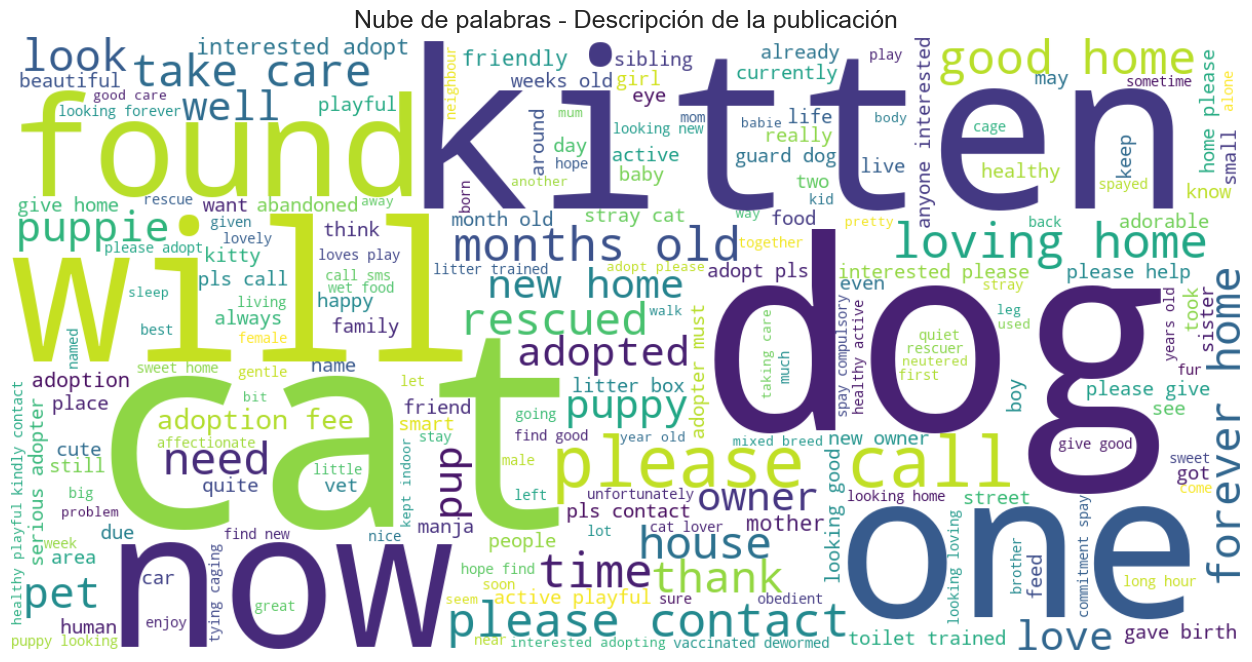

In [24]:
import re
from collections import Counter
from wordcloud import STOPWORDS

# Limpiar texto y preparar corpus
text = ' '.join(df['Description'].dropna().astype(str).str.lower())
text = re.sub(r'[^a-záéíóúñüç0-9\s]', ' ', text)
words = [w for w in text.split() if len(w) > 2 and w not in STOPWORDS]

# Calcular frecuencias
word_counts = Counter(words)
most_common = word_counts.most_common(30)

# Mostrar tabla de frecuencia
freq_df = pd.DataFrame(most_common, columns=['word', 'count'])
print('Top 30 palabras más frecuentes en Description:')
print(freq_df.head(20).to_string(index=False))

# Generar nube de palabras
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    stopwords=STOPWORDS,
    colormap='viridis'
).generate(' '.join(words))

plt.figure(figsize=(16, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Nube de palabras - Descripción de la publicación', fontsize=18)
plt.show()

### 1.2.1 Palabras clave en Description relacionadas con AdoptionSpeed

Creamos banderas para las palabras más frecuentes en la descripción y evaluamos su relación con la velocidad de adopción.

In [77]:
# Crear variables de presencia de palabras clave en la descripción
# y medir su relación con AdoptionSpeed.
top_words = [word for word, _ in most_common if len(word) > 2][:20]

def safe_keyword_col(word):
    return re.sub(r'[^a-z0-9_]', '_', word.lower().replace(' ', '_'))

for word in top_words:
    col_name = f'Desc_{safe_keyword_col(word)}'
    df[col_name] = df['Description'].fillna('').str.lower().str.contains(fr"\b{re.escape(word)}\b", regex=True).astype(int)

# Evaluar efecto en el target
summary = []
global_fast_rate = df['AdoptionSpeed'].isin([0, 1]).mean() * 100
global_mean_speed = df['AdoptionSpeed'].mean()

for word in top_words:
    col_name = f'Desc_{safe_keyword_col(word)}'
    present = df[df[col_name] == 1]['AdoptionSpeed']
    if present.empty:
        continue

    mean_speed = present.mean()
    fast_rate = present.isin([0, 1]).mean() * 100

    summary.append({
        'word': word,
        'count': int(present.shape[0]),
        'presence_pct': round(present.shape[0] / len(df) * 100, 2),
        'mean_speed_if_present': round(mean_speed, 3),
        'fast_rate_if_present': round(fast_rate, 2),
        'delta_fast_vs_global': round(fast_rate - global_fast_rate, 2),
        'delta_speed_vs_global': round(global_mean_speed - mean_speed, 3)
    })

keywords_df = pd.DataFrame(summary).sort_values('delta_fast_vs_global', ascending=False)

# Feature engineering usando palabras con mayor asociación positiva y negativa
positive_words = keywords_df.head(8)['word'].tolist()
negative_words = keywords_df.sort_values('delta_fast_vs_global').head(8)['word'].tolist()

positive_cols = []
negative_cols = []
for word in positive_words:
    col_name = f'Desc_pos_{safe_keyword_col(word)}'
    positive_cols.append(col_name)
    df[col_name] = df['Description'].fillna('').str.lower().str.contains(fr"\b{re.escape(word)}\b", regex=True).astype(int)

for word in negative_words:
    col_name = f'Desc_neg_{safe_keyword_col(word)}'
    negative_cols.append(col_name)
    df[col_name] = df['Description'].fillna('').str.lower().str.contains(fr"\b{re.escape(word)}\b", regex=True).astype(int)

# Agregar variables de conteo y flags
if positive_cols:
    df['Desc_Positive_Keyword_Count'] = df[positive_cols].sum(axis=1)
    df['Desc_Positive_Keyword_Flag'] = (df['Desc_Positive_Keyword_Count'] > 0).astype(int)
else:
    df['Desc_Positive_Keyword_Count'] = 0
    df['Desc_Positive_Keyword_Flag'] = 0

if negative_cols:
    df['Desc_Negative_Keyword_Count'] = df[negative_cols].sum(axis=1)
    df['Desc_Negative_Keyword_Flag'] = (df['Desc_Negative_Keyword_Count'] > 0).astype(int)
else:
    df['Desc_Negative_Keyword_Count'] = 0
    df['Desc_Negative_Keyword_Flag'] = 0

# Balance de palabras positivas vs negativas
if positive_cols or negative_cols:
    df['Desc_Keyword_Sentiment'] = df['Desc_Positive_Keyword_Count'] - df['Desc_Negative_Keyword_Count']
else:
    df['Desc_Keyword_Sentiment'] = 0

print('Features de texto basados en palabras clave creadas:')
print('  Positivas:', positive_words)
print('  Negativas:', negative_words)
print(df[['Desc_Positive_Keyword_Count', 'Desc_Negative_Keyword_Count', 'Desc_Positive_Keyword_Flag', 'Desc_Negative_Keyword_Flag', 'Desc_Keyword_Sentiment']].head())

print('Palabras clave con mayor asociación positiva a adopciones rápidas:')
print(keywords_df.head(15).to_string(index=False))

print('\nPalabras clave con mayor asociación a adopciones lentas:')
print(keywords_df.sort_values('delta_fast_vs_global').head(10).to_string(index=False))

C:\Users\julia\AppData\Local\Temp\ipykernel_40120\2214791455.py:52: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col_name] = df['Description'].fillna('').str.lower().str.contains(fr"\b{re.escape(word)}\b", regex=True).astype(int)
C:\Users\julia\AppData\Local\Temp\ipykernel_40120\2214791455.py:52: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col_name] = df['Description'].fillna('').str.lower().str.contains(fr"\b{re.escape(word)}\b", regex=True).astype(int)
C:\Users\julia\AppData\Local\Temp\ipykernel_40120\2214791455.py:52

Features de texto basados en palabras clave creadas:
  Positivas: ['kitten', 'cat', 'found', 'playful', 'old', 'adoption', 'call', 'interested']
  Negativas: ['dog', 'contact', 'give', 'good', 'loving', 'home', 'love', 'looking']
   Desc_Positive_Keyword_Count  Desc_Negative_Keyword_Count  \
0                            2                            1   
1                            1                            1   
2                            2                            1   
3                            2                            2   
4                            3                            5   

   Desc_Positive_Keyword_Flag  Desc_Negative_Keyword_Flag  \
0                           1                           1   
1                           1                           1   
2                           1                           1   
3                           1                           1   
4                           1                           1   

   Desc_Keyword_Sentimen

C:\Users\julia\AppData\Local\Temp\ipykernel_40120\2214791455.py:52: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col_name] = df['Description'].fillna('').str.lower().str.contains(fr"\b{re.escape(word)}\b", regex=True).astype(int)
C:\Users\julia\AppData\Local\Temp\ipykernel_40120\2214791455.py:56: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Desc_Positive_Keyword_Count'] = df[positive_cols].sum(axis=1)
C:\Users\julia\AppData\Local\Temp\ipykernel_40120\2214791455.py:57: PerformanceWarning: DataFrame is highly fragmented. 

### 1.3 Valores nulos

In [ ]:
nulls = train.isnull().sum().sort_values(ascending=False)
nulls_pct = (nulls / len(train) * 100).round(2)
null_df = pd.DataFrame({'Nulos': nulls, 'Porcentaje (%)': nulls_pct})
null_df[null_df['Nulos'] > 0]

,Nulos,Porcentaje (%)
Name,1265,8.44
Description,13,0.09


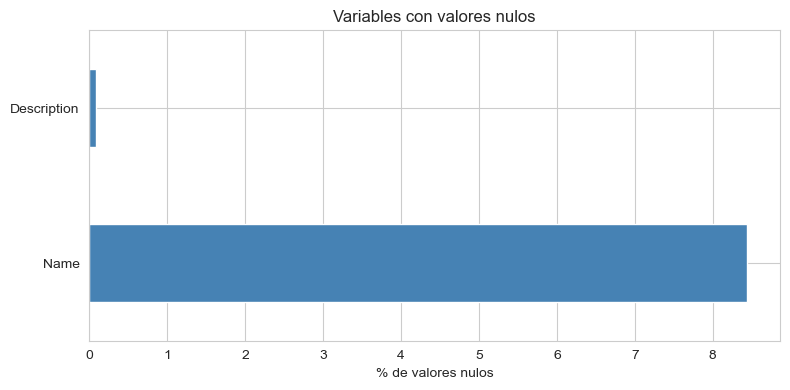

In [ ]:
# Visualización de nulos
cols_con_nulos = null_df[null_df['Nulos'] > 0]
plt.figure(figsize=(8, 4))
cols_con_nulos['Porcentaje (%)'].plot(kind='barh', color='steelblue')
plt.xlabel('% de valores nulos')
plt.title('Variables con valores nulos')
plt.tight_layout()
plt.show()

### 1.3 Mapeo de variables categóricas

Convertimos los códigos numéricos a etiquetas descriptivas para facilitar el análisis.

In [ ]:
df = train.copy()

# Mapeos según el diccionario de datos
df['Type']         = df['Type'].map({1: 'Perro', 2: 'Gato'})
df['Gender']       = df['Gender'].map({1: 'Macho', 2: 'Hembra', 3: 'Mixto'})
df['MaturitySize'] = df['MaturitySize'].map({0: 'No especif.', 1: 'Pequeño', 2: 'Mediano', 3: 'Grande', 4: 'Extra Grande'})
df['FurLength']    = df['FurLength'].map({0: 'No especif.', 1: 'Corto', 2: 'Mediano', 3: 'Largo'})
df['Vaccinated']   = df['Vaccinated'].map({1: 'Sí', 2: 'No', 3: 'No sabe'})
df['Dewormed']     = df['Dewormed'].map({1: 'Sí', 2: 'No', 3: 'No sabe'})
df['Sterilized']   = df['Sterilized'].map({1: 'Sí', 2: 'No', 3: 'No sabe'})
df['Health']       = df['Health'].map({0: 'No especif.', 1: 'Sano', 2: 'Lesión leve', 3: 'Lesión grave'})

# Unión con labels de colores, razas y estados
color_map = colors.set_index('ColorID')['ColorName'].to_dict()
state_map = states.set_index('StateID')['StateName'].to_dict()
breed_map = breeds.set_index('BreedID')['BreedName'].to_dict()

# Mapeo de variables con labels
df['State']  = df['State'].map(state_map)
df['Color1'] = df['Color1'].map(color_map)
df['Color2'] = df['Color2'].map(color_map)
df['Color3'] = df['Color3'].map(color_map)
df['Breed1'] = df['Breed1'].map(breed_map)
df['Breed2'] = df['Breed2'].map(breed_map)

# Variables derivadas
df['HasName'] = df['Name'].notna() & (df['Name'].str.strip() != '') # tiene nombre
df['IsMixed'] = (train['Breed2'] != 0).astype(int) # es mestizo
df['HasPhoto'] = (df['PhotoAmt'].fillna(0) > 0).astype(int) # tiene foto
df['HasVideo'] = (df['VideoAmt'] > 0).astype(int) # tiene video
df['IsFree'] = (df['Fee'] == 0).astype(int) # adopción gratuita

print('Dataset preparado.')
df.head(3)

Dataset preparado.


,Type,Name,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,FurLength,Vaccinated,Dewormed,Sterilized,Health,Quantity,Fee,State,RescuerID,VideoAmt,Description,PetID,PhotoAmt,AdoptionSpeed,HasName,IsMixed,HasPhoto,HasVideo,IsFree
0,Gato,Nibble,3,Tabby,NaN,Macho,Black,White,NaN,Pequeño,Corto,No,No,No,Sano,1,100,Selangor,8480853f516546f6cf33aa88cd76c379,0,Nibble is a 3+ month old ball of cuteness. He ...,86e1089a3,1.0,2,True,0,1,0,0
1,Gato,No Name Yet,1,Domestic Medium Hair,NaN,Macho,Black,Brown,NaN,Mediano,Mediano,No sabe,No sabe,No sabe,Sano,1,0,Kuala Lumpur,3082c7125d8fb66f7dd4bff4192c8b14,0,I just found it alone yesterday near my apartm...,6296e909a,2.0,0,True,0,1,0,1
2,Perro,Brisco,1,Mixed Breed,NaN,Macho,Brown,White,NaN,Mediano,Mediano,Sí,Sí,No,Sano,1,0,Selangor,fa90fa5b1ee11c86938398b60abc32cb,0,Their pregnant mother was dumped by her irresp...,3422e4906,7.0,3,True,0,1,0,1


### 1.4 Estadísticas descriptivas

In [ ]:
num_cols = ['Age', 'Quantity', 'Fee', 'VideoAmt', 'PhotoAmt']

df[num_cols].describe()

,Age,Quantity,Fee,VideoAmt,PhotoAmt
count,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000
mean,10.452078,1.576069,21.259988,0.056760,3.889215
std,18.155790,1.472477,78.414548,0.346185,3.487810
min,0.000000,1.000000,0.000000,0.000000,0.000000
25%,2.000000,1.000000,0.000000,0.000000,2.000000
50%,3.000000,1.000000,0.000000,0.000000,3.000000
75%,12.000000,1.000000,0.000000,0.000000,5.000000
max,255.000000,20.000000,3000.000000,8.000000,30.000000


In [ ]:
df.describe(include='object')

,Type,Name,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,FurLength,Vaccinated,Dewormed,Sterilized,Health,State,RescuerID,Description,PetID
count,14993,13728,14988,4231,14993,14993,10522,4389,14993,14993,14993,14993,14993,14993,14993,14993,14980,14993
unique,2,9059,175,134,3,7,6,5,4,3,3,3,3,3,14,5595,14031,14993
top,Perro,Baby,Mixed Breed,Mixed Breed,Hembra,Black,White,White,Mediano,Corto,No,Sí,No,Sano,Selangor,fa90fa5b1ee11c86938398b60abc32cb,For Adoption,86e1089a3
freq,8132,66,5927,1727,7277,7427,3438,3221,10305,8808,7227,8397,10077,14478,8714,459,164,1


---
## 2. Análisis Univariado

### 2.1 Variable target: AdoptionSpeed

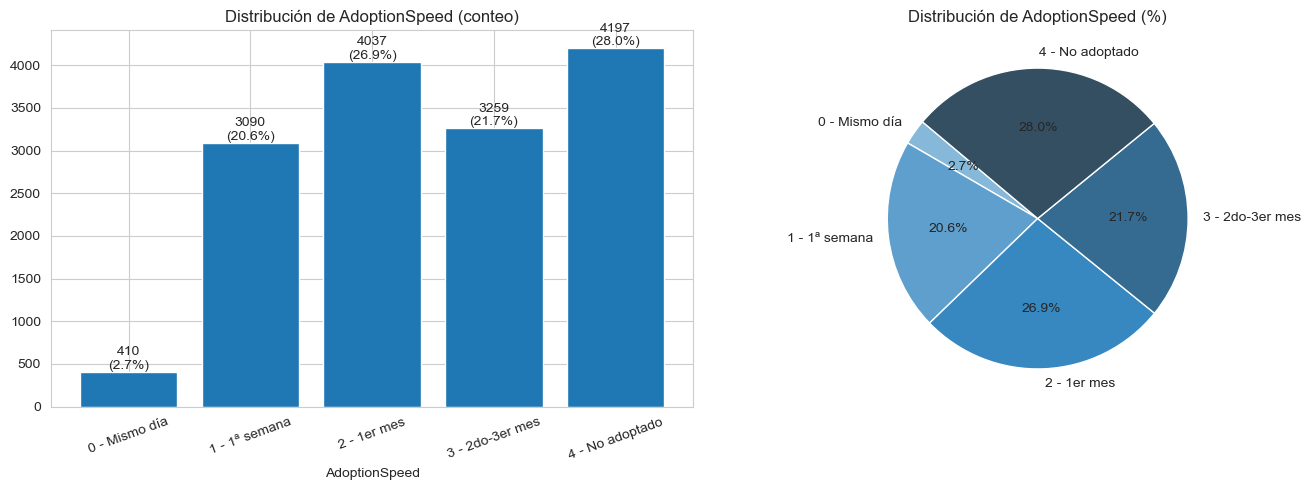

In [ ]:
target_labels = {
    0: '0 - Mismo día',
    1: '1 - 1ª semana',
    2: '2 - 1er mes',
    3: '3 - 2do-3er mes',
    4: '4 - No adoptado'
}

counts = df['AdoptionSpeed'].value_counts().sort_index()
pcts   = counts / counts.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].bar(
    [target_labels[i] for i in counts.index],
    counts.values
)

axes[0].set_title('Distribución de AdoptionSpeed (conteo)')
axes[0].set_xlabel('AdoptionSpeed')
axes[0].tick_params(axis='x', rotation=20)

for i, bar in enumerate(bars):
    height = bar.get_height()
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{counts.iloc[i]}\n({pcts.iloc[i]:.1f}%)',
        ha='center',
        va='bottom'
    )

axes[1].pie(
    pcts.values,
    labels=[target_labels[i] for i in pcts.index],
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('Blues_d', len(pcts))
)

axes[1].set_title('Distribución de AdoptionSpeed (%)')

plt.tight_layout()
plt.show()

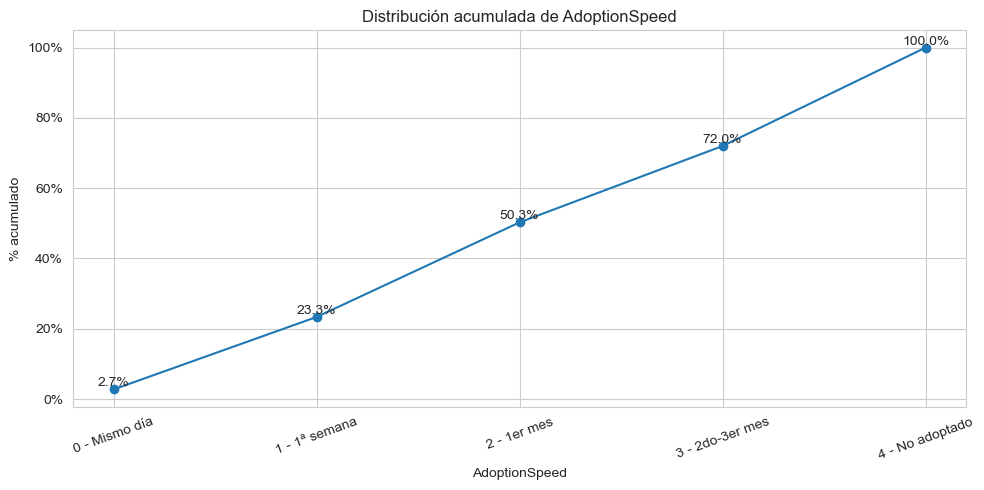

In [ ]:
# Distribución acumulada
cum_pct = pcts.cumsum()

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    [target_labels[i] for i in cum_pct.index],
    cum_pct.values,
    marker="o"
)

ax.set_title("Distribución acumulada de AdoptionSpeed")
ax.set_xlabel("AdoptionSpeed")
ax.set_ylabel("% acumulado")

ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.tick_params(axis='x', rotation=20)

for i, value in enumerate(cum_pct.values):
    ax.text(
        i,
        value,
        f"{value:.1f}%",
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

La distribución de `AdoptionSpeed` muestra que las categorías más frecuentes son la 4 (28%) y la 2 (26.9%), mientras que la adopción inmediata (clase 0) es muy poco frecuente (2.7%).

La distribución acumulada muestra que:
*   Aproximadamente el 50% de las mascotas se adopta dentro del primer mes (clases 0-2).
*   Cerca del 70% se adoptan dentro de los 3 meses (clases 0–3).
*   El 30% restante no se adopta en ese período (clase 4).

### 2.2 Tipo de animal

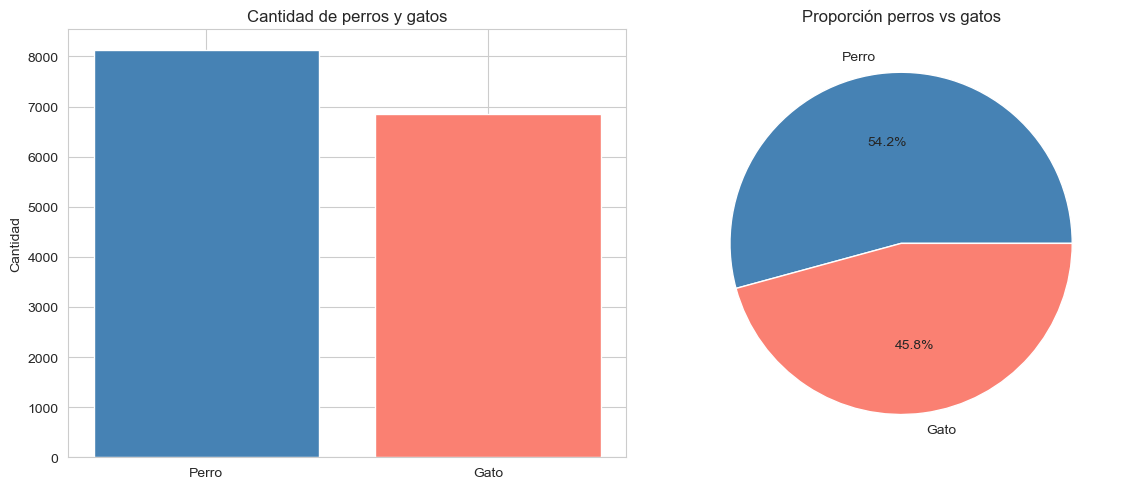

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
vc = df['Type'].value_counts()
axes[0].bar(vc.index, vc.values, color=['steelblue', 'salmon'])
axes[0].set_title('Cantidad de perros y gatos')
axes[0].set_ylabel('Cantidad')

axes[1].pie(vc.values, labels=vc.index, autopct='%1.1f%%', colors=['steelblue', 'salmon'])
axes[1].set_title('Proporción perros vs gatos')

plt.tight_layout()
plt.show()

### 2.3 Variables numéricas continuas

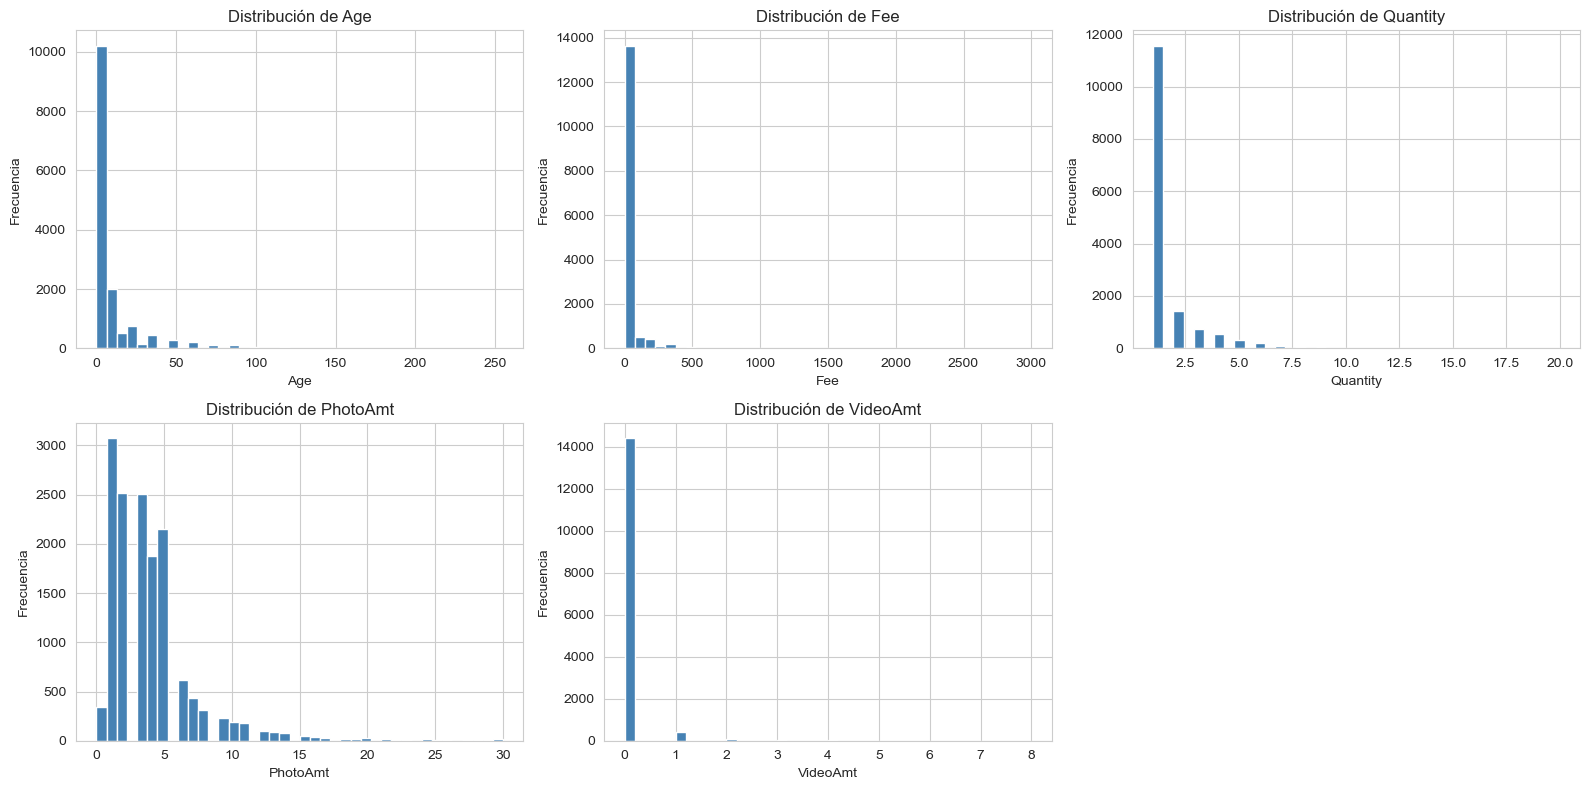

In [ ]:
num_cols = ['Age', 'Fee', 'Quantity', 'PhotoAmt', 'VideoAmt']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=40, color='steelblue', edgecolor='white')
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')

axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

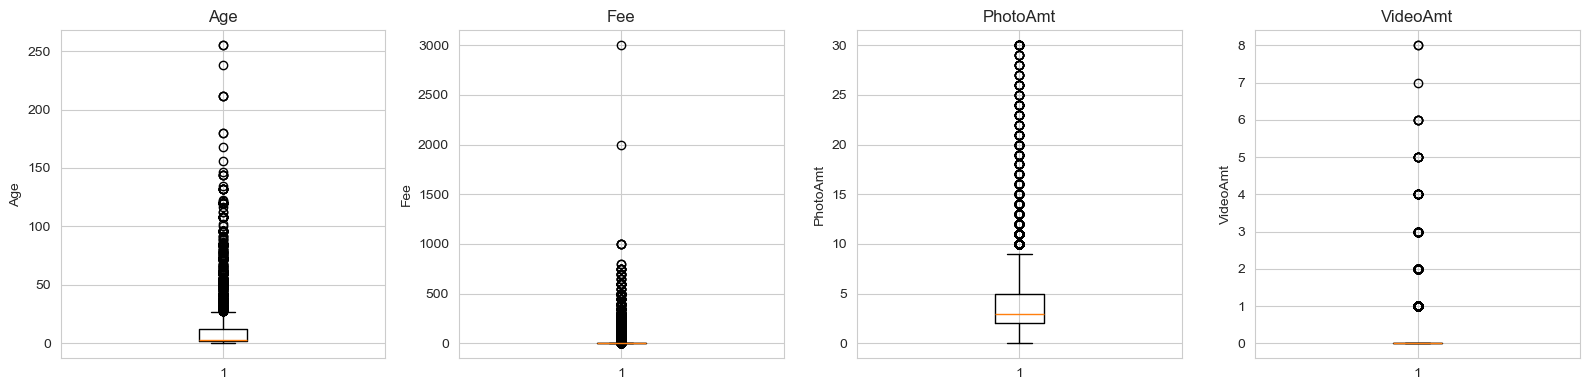

In [ ]:
num_cols_plot = ['Age', 'Fee', 'PhotoAmt', 'VideoAmt']

fig, axes = plt.subplots(1, len(num_cols_plot), figsize=(4*len(num_cols_plot), 4))

if len(num_cols_plot) == 1:
    axes = [axes]

for ax, col in zip(axes, num_cols_plot):
    ax.boxplot(df[col].dropna(), vert=True)      
    ax.set_title(col)
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

In [ ]:
# Estadísticas de variables numéricas clave
df[num_cols].describe().round(2)

,Age,Fee,Quantity,PhotoAmt,VideoAmt
count,14993.00,14993.00,14993.00,14993.00,14993.00
mean,10.45,21.26,1.58,3.89,0.06
std,18.16,78.41,1.47,3.49,0.35
min,0.00,0.00,1.00,0.00,0.00
25%,2.00,0.00,1.00,2.00,0.00
50%,3.00,0.00,1.00,3.00,0.00
75%,12.00,0.00,1.00,5.00,0.00
max,255.00,3000.00,20.00,30.00,8.00


- Las variables presentan fuerte asimetría y presencia de outliers, con concentración en valores bajos.
- La mayoría de las mascotas son jóvenes, lo que puede influir en la adopción.
- Las adopciones son principalmente gratuitas, por lo que Fee tiene poca variabilidad.
- PhotoAmt y DescLength destacan como variables con mayor potencial explicativo.

### 2.4 Variables categóricas

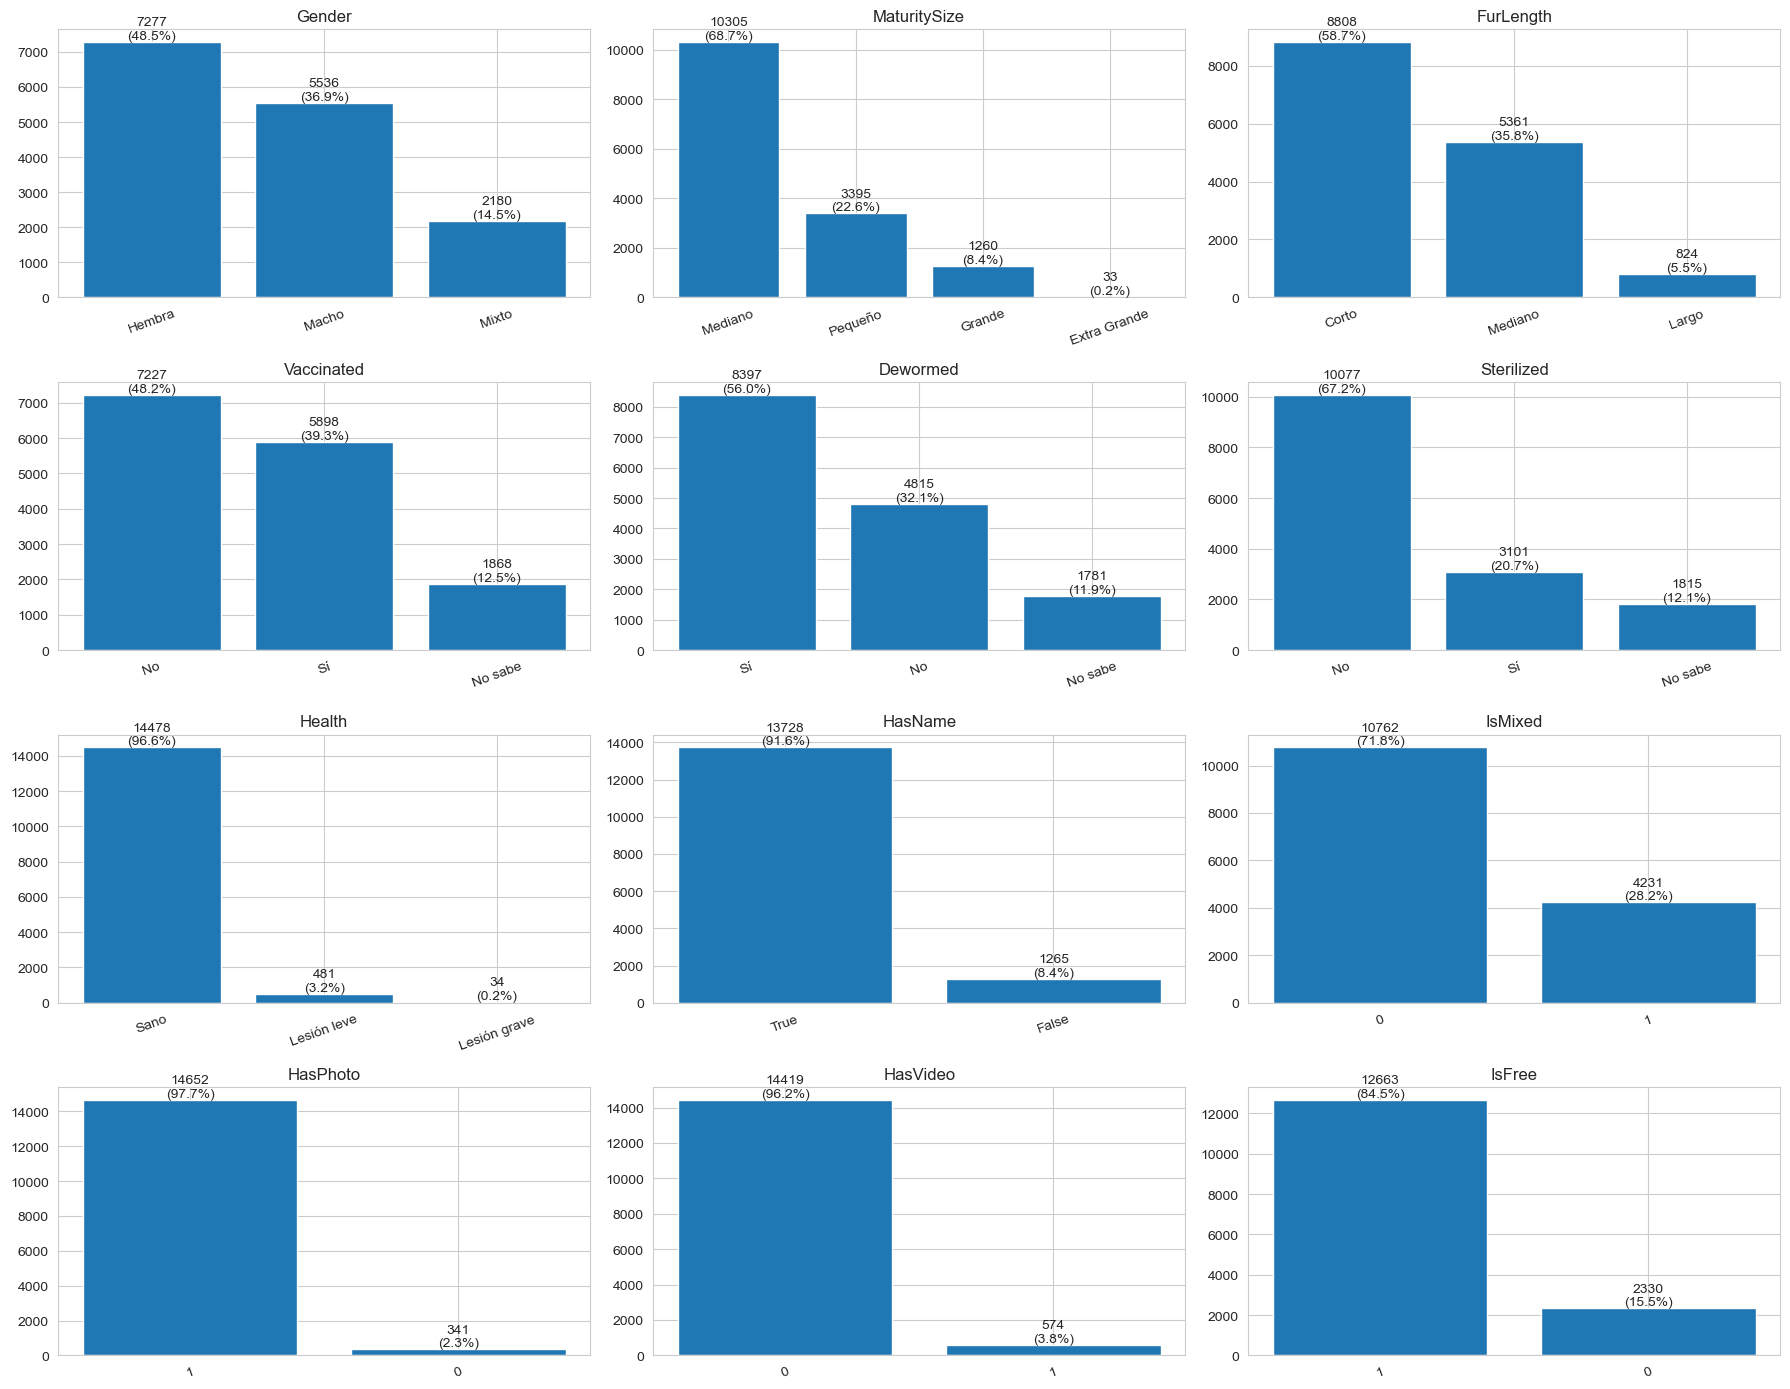

In [ ]:
cat_cols = [
    'Gender', 'MaturitySize', 'FurLength',
    'Vaccinated', 'Dewormed', 'Sterilized', 'Health',
    'HasName', 'IsMixed', 'HasPhoto', 'HasVideo', 'IsFree'
]

fig, axes = plt.subplots(4, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    vc = df[col].value_counts()
    total = vc.sum()
    pct = vc / total * 100

    axes[i].bar(vc.index.astype(str), vc.values)
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=20)

    for j, v in enumerate(vc.values):
        axes[i].text(
            j,
            v,
            f"{v}\n({pct.iloc[j]:.1f}%)",
            ha='center',
            va='bottom'
        )

# ocultar subplots vacíos
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

- Predominan las hembras frente a machos y mixtos.
- La mayoría de los animales son de tamaño mediano y pelo corto, siendo minoría los de tamaño extremo y pelo largo.
- En cuanto al estado sanitario, la mayor parte de los animales están sanos, aunque muchos no están vacunados, desparasitados o esterilizados.
- Destaca que muchos animales no están esterilizados, lo que puede influir en su adopción.
- Entre las variables derivadas, la gran mayoría tiene nombre y publicaciones con fotos, lo cual podría favorecer la adopción. Sólo un breve porcentaje tiene videos.
- Predominan los animales no mestizos, aunque hay una proporción relevante de mestizos.
- Muchos animales son de adopción gratuita, lo que podría afectar la rapidez de adopción.

### 2.5 Distribución geográfica (Estado)

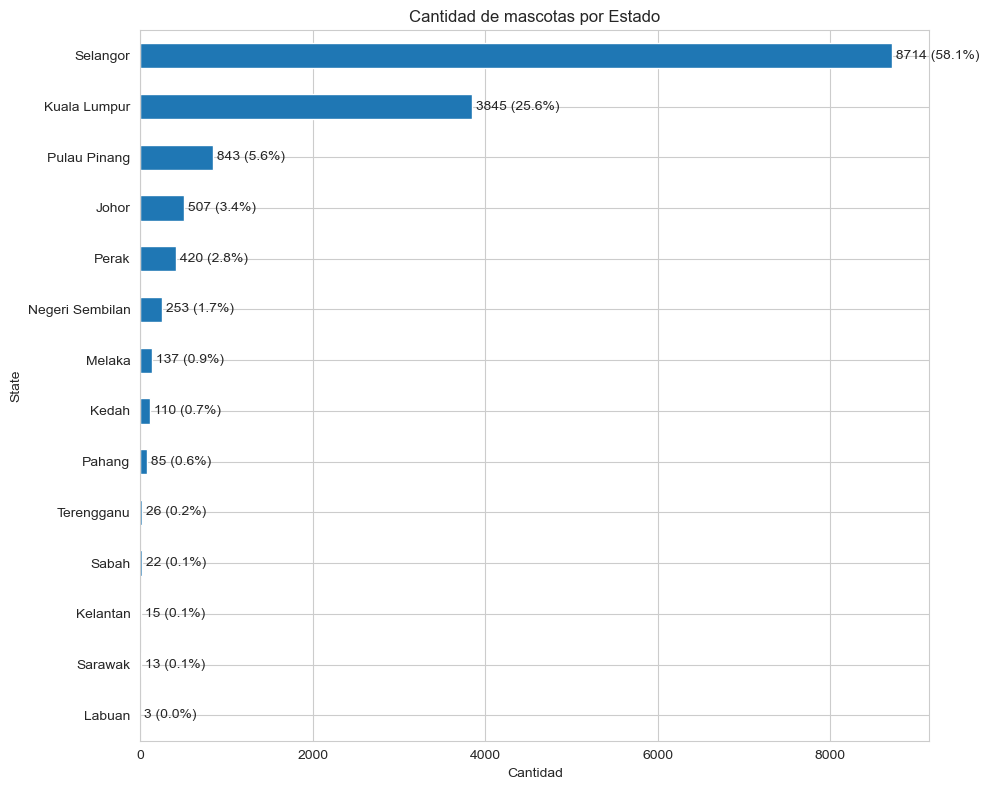

In [ ]:
state_counts = df['State'].value_counts().sort_values(ascending=True)
state_pct = state_counts / state_counts.sum() * 100

plt.figure(figsize=(10, 8))
ax = state_counts.plot(kind='barh')

plt.title('Cantidad de mascotas por Estado')
plt.xlabel('Cantidad')

for i, v in enumerate(state_counts.values):
    ax.text(
        v,
        i,
        f' {v} ({state_pct.iloc[i]:.1f}%)',
        va='center'
    )

plt.tight_layout()
plt.show()

### 2.6 Nombres más frecuentes

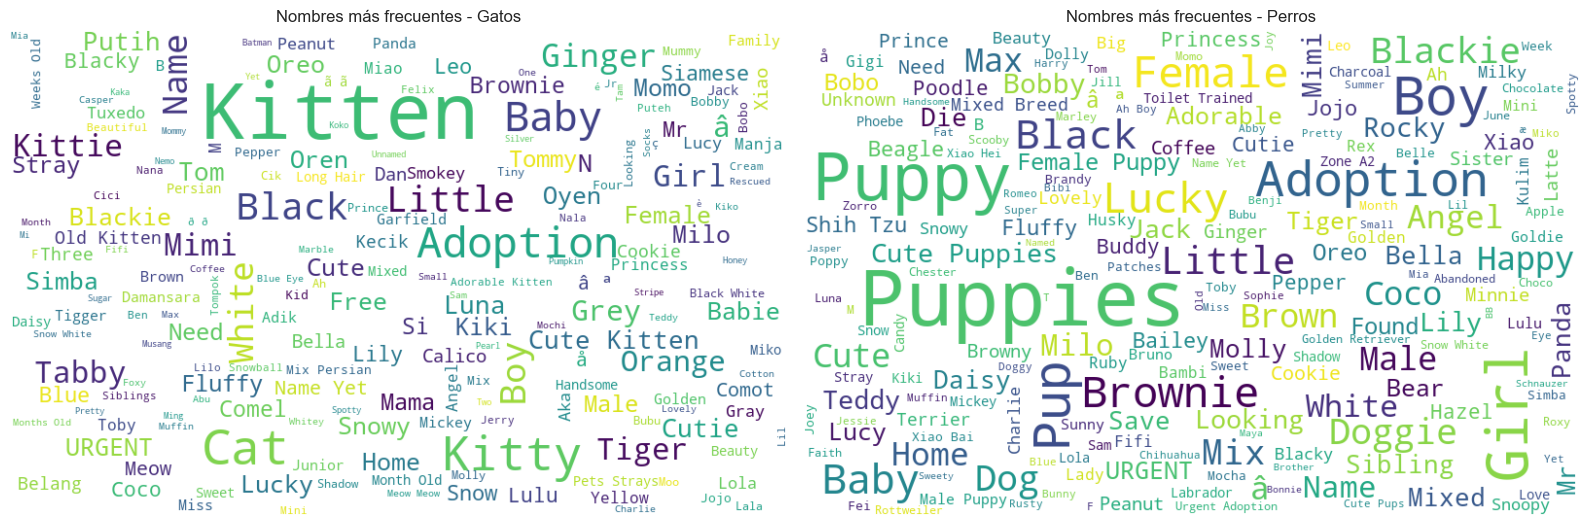

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, tipo in zip(axes, ['Gato', 'Perro']):
    text = ' '.join(df.loc[df['Type'] == tipo, 'Name'].dropna().values)
    if text.strip():
        wc = WordCloud(max_font_size=80, background_color='white',
                       width=800, height=500).generate(text)
        ax.imshow(wc, interpolation='bilinear')
        ax.set_title(f'Nombres más frecuentes - {tipo}s')
        ax.axis('off')

plt.tight_layout()
plt.show()

---
## 3. Análisis Bivariado (relación con AdoptionSpeed)

In [ ]:
# Función auxiliar: tasa de adopción rápida (clases 0+1) por categoría
def adoption_rate_by(col, df=df, fast_classes=(0, 1)):
    """Calcula % de adopción rápida por categoría."""
    result = df.groupby(col)['AdoptionSpeed'].apply(
        lambda x: (x.isin(fast_classes)).mean() * 100
    ).sort_values(ascending=False)
    return result

### 3.1 AdoptionSpeed según tipo de animal

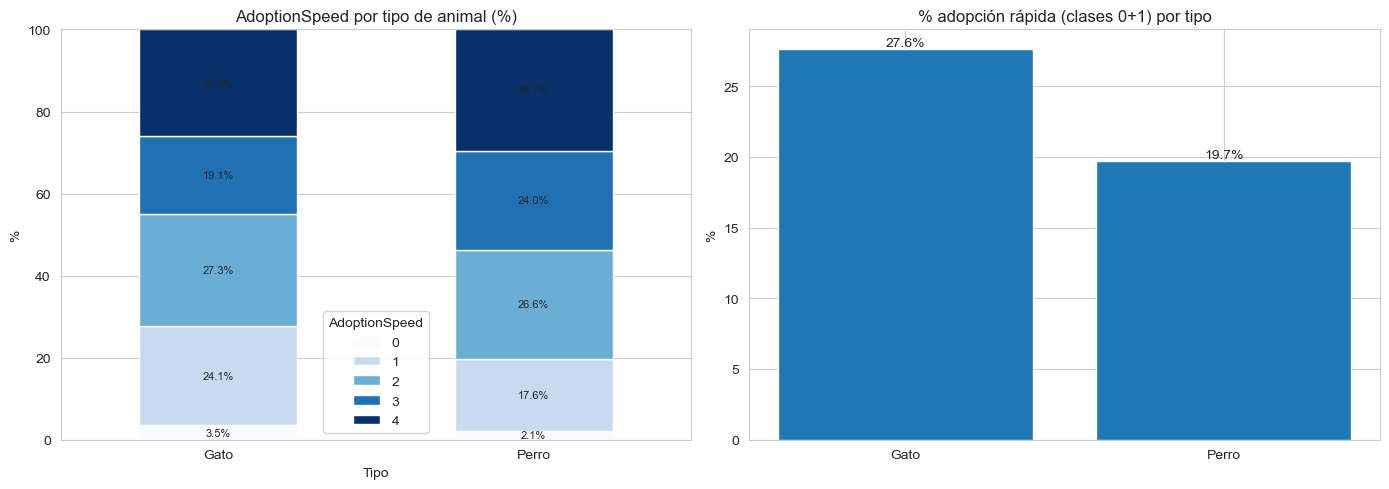

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# izquierda
cross = df.groupby(['Type', 'AdoptionSpeed']).size().unstack(fill_value=0)
cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100

cross_pct.plot(kind='bar', stacked=True, ax=axes[0], colormap='Blues', edgecolor='white')

axes[0].set_title('AdoptionSpeed por tipo de animal (%)')
axes[0].set_xlabel('Tipo')
axes[0].set_ylabel('%')
axes[0].set_ylim(0, 100)
axes[0].tick_params(axis='x', rotation=0)

for i, tipo in enumerate(cross_pct.index):
    cumulative = 0
    for speed in cross_pct.columns:
        pct = cross_pct.loc[tipo, speed]

        if pct > 0:
            axes[0].text(
                i,
                cumulative + pct / 2,
                f'{pct:.1f}%',
                ha='center',
                va='center',
                fontsize=8
            )
        cumulative += pct

# Derecha
rate = adoption_rate_by('Type')

bars = axes[1].bar(rate.index, rate.values)

axes[1].set_title('% adopción rápida (clases 0+1) por tipo')
axes[1].set_ylabel('%')
axes[1].tick_params(axis='x', rotation=0)

# 👉 etiquetas (%)
for i, v in enumerate(rate.values):
    axes[1].text(
        i,
        v,
        f'{v:.1f}%',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

El tipo de animal parece influir en la velocidad de adopción. Los gatos tienden a adoptarse más rápido que los perros, mientras que los perros tienen mayor peso en clases más lentas (especialmente 3 y 4), lo que sugiere más dificultad para ser adoptados.

### 3.2 Edad y AdoptionSpeed

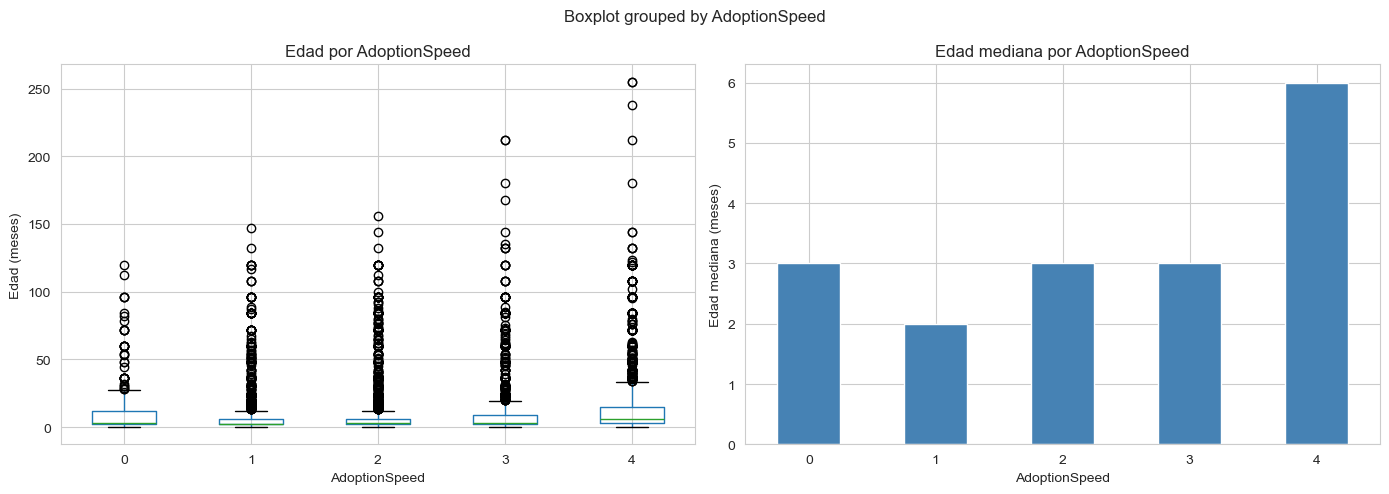

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot de edad por clase de adopción
df.boxplot(column='Age', by='AdoptionSpeed', ax=axes[0])
axes[0].set_title('Edad por AdoptionSpeed')
axes[0].set_xlabel('AdoptionSpeed')
axes[0].set_ylabel('Edad (meses)')
plt.sca(axes[0])
plt.title('Edad por AdoptionSpeed')

# Edad promedio por clase
age_mean = df.groupby('AdoptionSpeed')['Age'].median()
age_mean.plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Edad mediana por AdoptionSpeed')
axes[1].set_xlabel('AdoptionSpeed')
axes[1].set_ylabel('Edad mediana (meses)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

Edad y velocidad de adopción tiene una relacion positiva: las mascotas más jóvenes tienden a adoptarse más rápido, mientras que a mayor edad aumenta la probabilidad de una adopción lenta. En las adopciones más lentas (especialmente clase 4), la edad mediana aumenta notablemente (≈6 meses), indicando mayor dificultad para adoptar animales más mayores.

### 3.3 Variables de salud y AdoptionSpeed

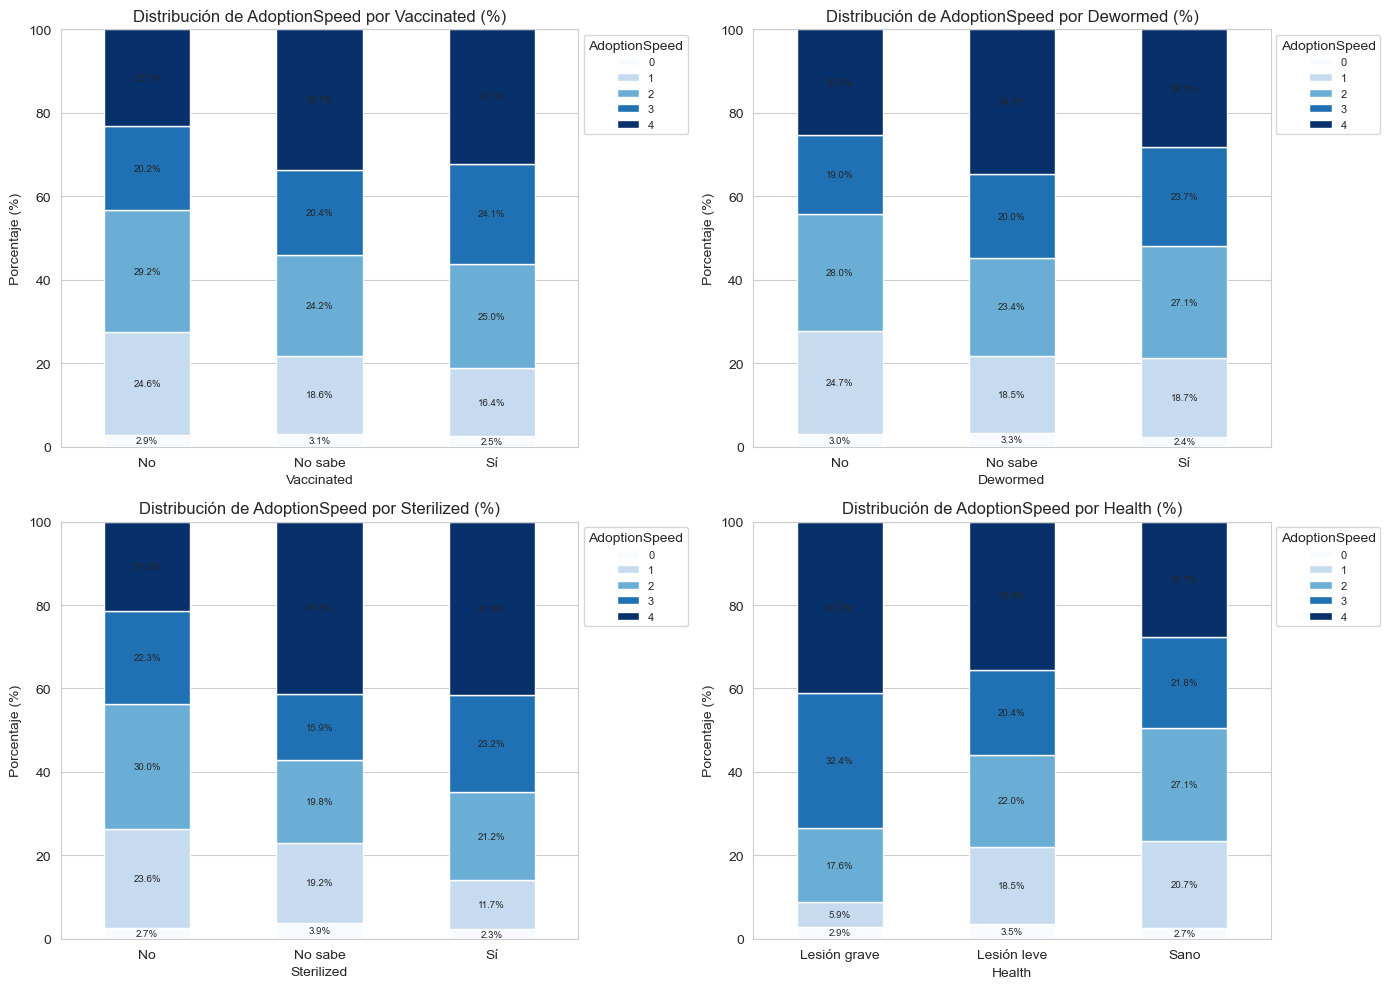

In [ ]:
health_cols = ['Vaccinated', 'Dewormed', 'Sterilized', 'Health']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(health_cols):
    # Calcular proporciones
    cross = df.groupby([col, 'AdoptionSpeed']).size().unstack(fill_value=0)
    cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100

    cross_pct.plot(kind='bar', stacked=True, ax=axes[i], colormap='Blues', edgecolor='white')

    axes[i].set_title(f'Distribución de AdoptionSpeed por {col} (%)')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Porcentaje (%)')
    axes[i].set_ylim(0, 100)
    axes[i].tick_params(axis='x', rotation=0)

    axes[i].legend(title='AdoptionSpeed', fontsize=8, loc='upper left', bbox_to_anchor=(1, 1))

    for j, category in enumerate(cross_pct.index):
        cumulative = 0
        for speed in cross_pct.columns:
            pct = cross_pct.loc[category, speed]

            if pct > 0:
                axes[i].text(
                    j,
                    cumulative + pct / 2,
                    f'{pct:.1f}%',
                    ha='center',
                    va='center',
                    fontsize=7
                )
            cumulative += pct

plt.tight_layout()
plt.show()

El estado de salud parcece ser la variable más influyente: los animales sanos tienen mayor proporción de adopciones rápidas, y los que presentan lesiones (especialmente graves) se concentran en clases más altas.

El hecho de que las adopciones rápidas parecieran presentarse con más frecuencias en animales no vacunados, desparacitados o esterilizados puede puede estar mediado por otras características, como la edad.

### 3.4 Fee (tarifa) y AdoptionSpeed

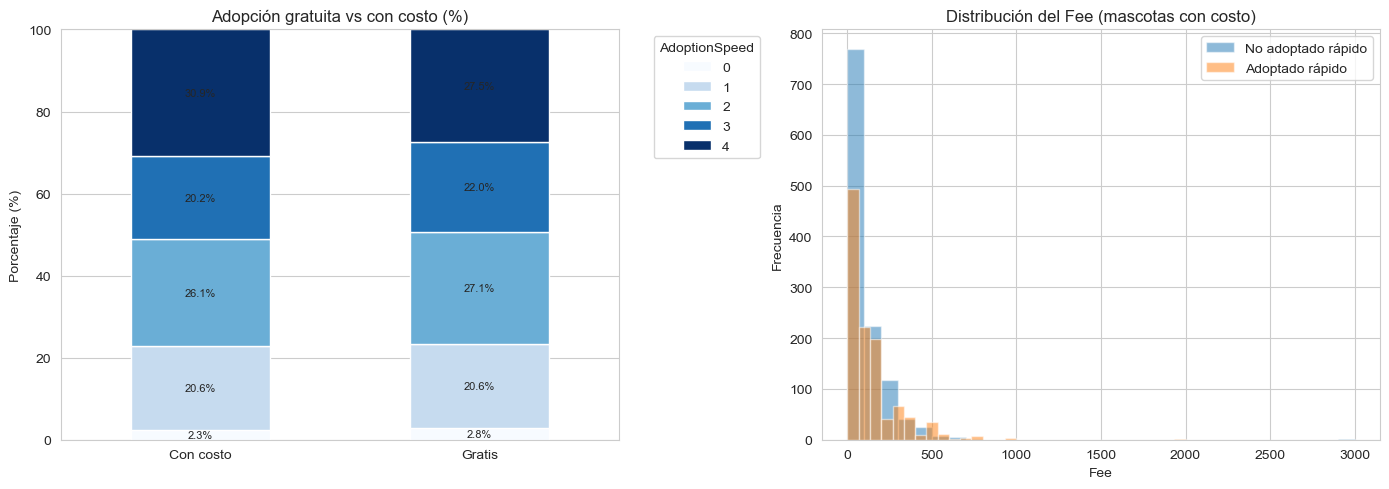

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Gratis vs pago (izquierda)
cross = df.groupby(['IsFree', 'AdoptionSpeed']).size().unstack(fill_value=0)
cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100
# Ajustamos los índices para que coincidan con la lógica de tu dataset
cross_pct.index = ['Con costo', 'Gratis']

cross_pct.plot(kind='bar', stacked=True, ax=axes[0], colormap='Blues', edgecolor='white')

axes[0].set_title('Adopción gratuita vs con costo (%)')
axes[0].set_ylabel('Porcentaje (%)')
axes[0].set_ylim(0, 100)
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='AdoptionSpeed', bbox_to_anchor=(1.05, 1), loc='upper left')

for i, category in enumerate(cross_pct.index):
    cumulative = 0
    for speed in cross_pct.columns:
        pct = cross_pct.loc[category, speed]

        if pct > 0:
            axes[0].text(
                i,
                cumulative + pct / 2,
                f'{pct:.1f}%',
                ha='center',
                va='center',
                fontsize=8
            )
        cumulative += pct

# 2. Distribución del fee para adoptados rápido vs lento (derecha)
df_fee = df[df['Fee'] > 0].copy()
# Definimos rápido como clases 0, 1 y 2
df_fee['Rapido'] = df_fee['AdoptionSpeed'].isin([0, 1, 2])

# Graficamos histogramas solapados
for status, group in df_fee.groupby('Rapido'):
    label = 'Adoptado rápido' if status else 'No adoptado rápido'
    axes[1].hist(group['Fee'], bins=30, alpha=0.5, label=label, edgecolor='white')

axes[1].set_title('Distribución del Fee (mascotas con costo)')
axes[1].set_xlabel('Fee')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

plt.tight_layout()
plt.show()

Las diferencias son pequeñas, pero las mascotas con costo concentran un poco más en adopciones lentas (especialmente clase 4). La distribución muestra que la mayoría de los precios están muy concentrados en valores bajos y que las mascotas adoptadas rápido tienden a tener fees más bajos.


### 3.5 Fotos, Videos y AdoptionSpeed

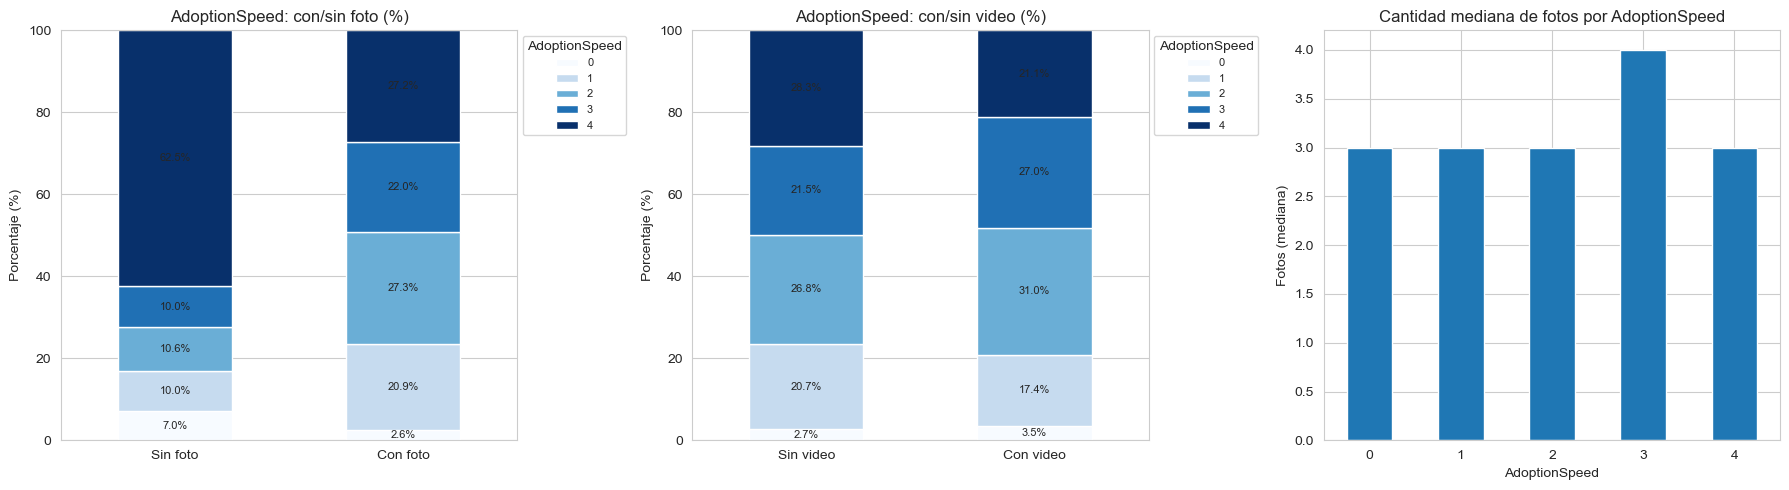

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Fotos (izquierda)
cross = df.groupby(['HasPhoto', 'AdoptionSpeed']).size().unstack(fill_value=0)
cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100
cross_pct.index = ['Sin foto', 'Con foto']

cross_pct.plot(kind='bar', stacked=True, ax=axes[0], colormap='Blues', edgecolor='white')

axes[0].set_title('AdoptionSpeed: con/sin foto (%)')
axes[0].set_ylabel('Porcentaje (%)')
axes[0].set_ylim(0, 100)
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='AdoptionSpeed', fontsize=8, loc='upper left', bbox_to_anchor=(1, 1))

for i, category in enumerate(cross_pct.index):
    cumulative = 0
    for speed in cross_pct.columns:
        pct = cross_pct.loc[category, speed]
        if pct > 0:
            axes[0].text(i, cumulative + pct/2, f'{pct:.1f}%', ha='center', va='center', fontsize=8)
        cumulative += pct

# Video (centro)
cross2 = df.groupby(['HasVideo', 'AdoptionSpeed']).size().unstack(fill_value=0)
cross2_pct = cross2.div(cross2.sum(axis=1), axis=0) * 100
cross2_pct.index = ['Sin video', 'Con video']

cross2_pct.plot(kind='bar', stacked=True, ax=axes[1], colormap='Blues', edgecolor='white')

axes[1].set_title('AdoptionSpeed: con/sin video (%)')
axes[1].set_ylabel('Porcentaje (%)')
axes[1].set_ylim(0, 100)
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='AdoptionSpeed', fontsize=8, loc='upper left', bbox_to_anchor=(1, 1))

for i, category in enumerate(cross2_pct.index):
    cumulative = 0
    for speed in cross2_pct.columns:
        pct = cross2_pct.loc[category, speed]
        if pct > 0:
            axes[1].text(i, cumulative + pct/2, f'{pct:.1f}%', ha='center', va='center', fontsize=8)
        cumulative += pct

# Mediana fotos (derecha)
df.groupby('AdoptionSpeed')['PhotoAmt'].median().plot(
    kind='bar',
    ax=axes[2],
    edgecolor='white'
)

axes[2].set_title('Cantidad mediana de fotos por AdoptionSpeed')
axes[2].set_xlabel('AdoptionSpeed')
axes[2].set_ylabel('Fotos (mediana)')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

La ausencia de fotos se asocia fuertemente con una mayor proporción de no adopción. La presencia de video también se asocia con mejores resultados de adopción, pero número de casos es bajo.

### 3.6 Género y AdoptionSpeed

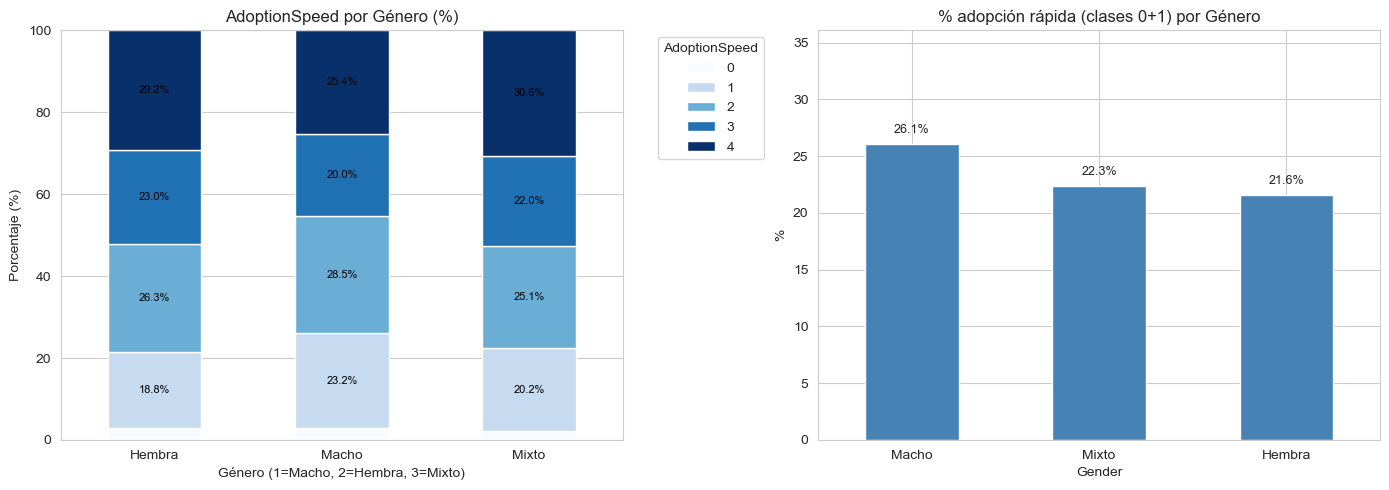

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. AdoptionSpeed por Género (izquierda)
cross = df.groupby(['Gender', 'AdoptionSpeed']).size().unstack(fill_value=0)
cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100

ax0 = cross_pct.plot(kind='bar', stacked=True, ax=axes[0], colormap='Blues', edgecolor='white')

for i, row in enumerate(cross_pct.values):
    acumulado = 0
    for j, val in enumerate(row):
        if val > 3:  # evitar etiquetas en segmentos muy chicos
            ax0.text(i, acumulado + val / 2, f'{val:.1f}%',
                     ha='center', va='center', fontsize=8, color='black')
        acumulado += val

axes[0].set_title('AdoptionSpeed por Género (%)')
axes[0].set_xlabel('Género (1=Macho, 2=Hembra, 3=Mixto)')
axes[0].set_ylabel('Porcentaje (%)')
axes[0].set_ylim(0, 100)
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='AdoptionSpeed', bbox_to_anchor=(1.05, 1), loc='upper left')

# Tasa de adopción rápida por Género (derecha)
rate = adoption_rate_by('Gender')
ax1 = rate.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='white')

for i, val in enumerate(rate.values):
    ax1.text(i, val + 1, f'{val:.1f}%', ha='center', fontsize=9)

axes[1].set_title('% adopción rápida (clases 0+1) por Género')
axes[1].set_ylabel('%')
axes[1].set_ylim(0, rate.max() + 10)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

Los machos muestran una tendencia a adoptarse más rápido.

### 3.7 Nombre y AdoptionSpeed

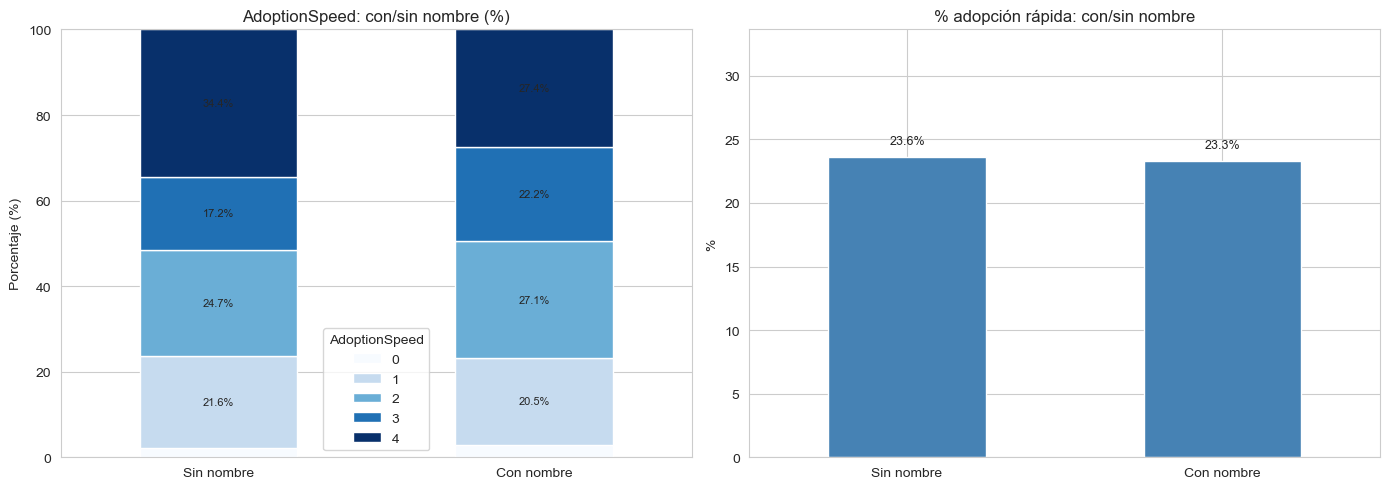

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cross = df.groupby(['HasName', 'AdoptionSpeed']).size().unstack(fill_value=0)
cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100
cross_pct.index = ['Sin nombre', 'Con nombre']

ax0 = cross_pct.plot(kind='bar', stacked=True, ax=axes[0],
                     colormap='Blues', edgecolor='white')

for i, row in enumerate(cross_pct.values):
    acumulado = 0
    for val in row:
        if val > 3:  # evita ruido visual
            ax0.text(i, acumulado + val/2, f'{val:.1f}%',
                     ha='center', va='center', fontsize=8)
        acumulado += val

axes[0].set_title('AdoptionSpeed: con/sin nombre (%)')
axes[0].set_ylabel('Porcentaje (%)')
axes[0].set_ylim(0, 100)
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='AdoptionSpeed')

rate = df.groupby('HasName')['AdoptionSpeed'].apply(
    lambda x: (x.isin([0, 1])).mean() * 100
)
rate.index = ['Sin nombre', 'Con nombre']

ax1 = rate.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='white')

for i, val in enumerate(rate.values):
    ax1.text(i, val + 1, f'{val:.1f}%', ha='center', fontsize=9)

axes[1].set_title('% adopción rápida: con/sin nombre')
axes[1].set_ylabel('%')
axes[1].set_ylim(0, rate.max() + 10)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

No se observan diferencias relevantes en la velocidad de adopción entre animales con y sin nombre.

### 3.8 Estado geográfico y AdoptionSpeed

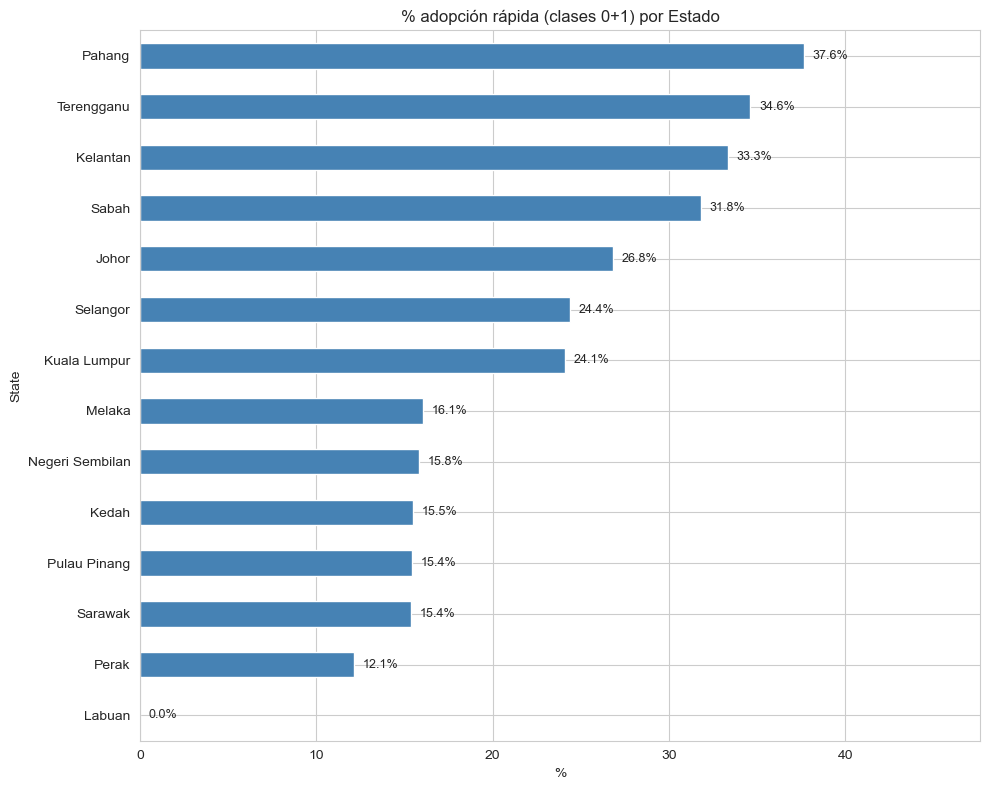

In [ ]:
rate_state = adoption_rate_by('State').sort_values()

plt.figure(figsize=(10, 8))
ax = rate_state.plot(kind='barh', color='steelblue', edgecolor='white')

for i, val in enumerate(rate_state.values):
    ax.text(val + 0.5, i, f'{val:.1f}%', va='center', fontsize=9)

plt.title('% adopción rápida (clases 0+1) por Estado')
plt.xlabel('%')
plt.xlim(0, rate_state.max() + 10)  # margen para que entren los labels
plt.tight_layout()
plt.show()

### 3.9 Cantidad de mascotas (Quantity) y AdoptionSpeed

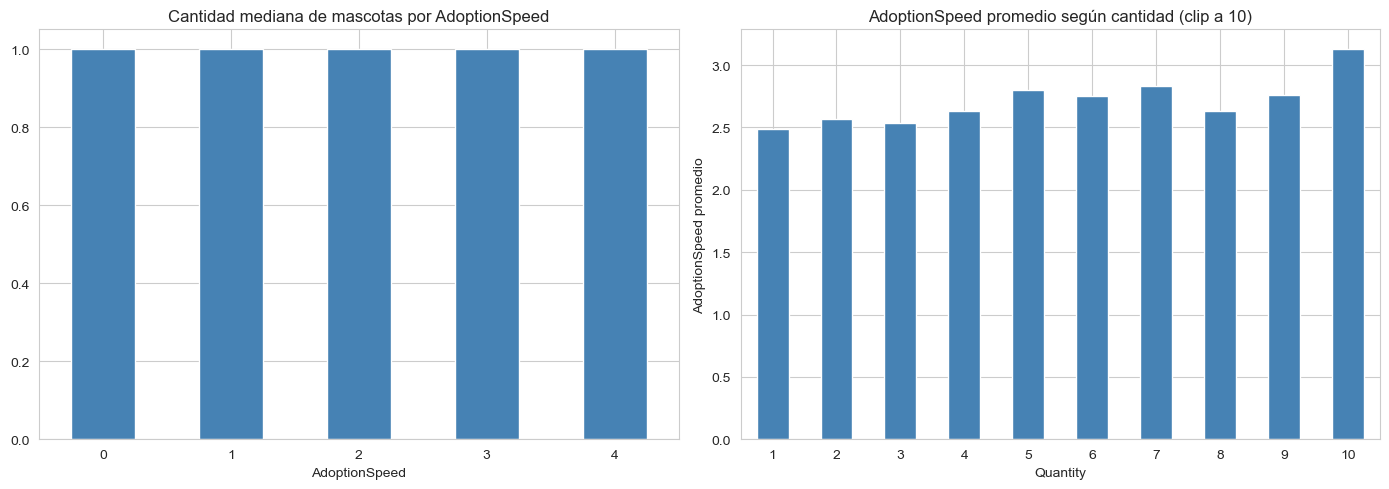

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df.groupby('AdoptionSpeed')['Quantity'].median().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Cantidad mediana de mascotas por AdoptionSpeed')
axes[0].set_xlabel('AdoptionSpeed')
axes[0].tick_params(axis='x', rotation=0)

# Distribución de quantity
q_clip = df['Quantity'].clip(upper=10)
q_cross = df.groupby(q_clip)['AdoptionSpeed'].mean()
q_cross.plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('AdoptionSpeed promedio según cantidad (clip a 10)')
axes[1].set_xlabel('Quantity')
axes[1].set_ylabel('AdoptionSpeed promedio')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

La mayoría de las publicaciones son de una sola mascota, independientemente del resultado de adopción. Se observa que a medida que aumenta la cantidad, la velocidad de adopción promedio también aumenta, es decir, emperora. Publicaciones con más animales tienden a tardar más en lograr adopciones rápidas.

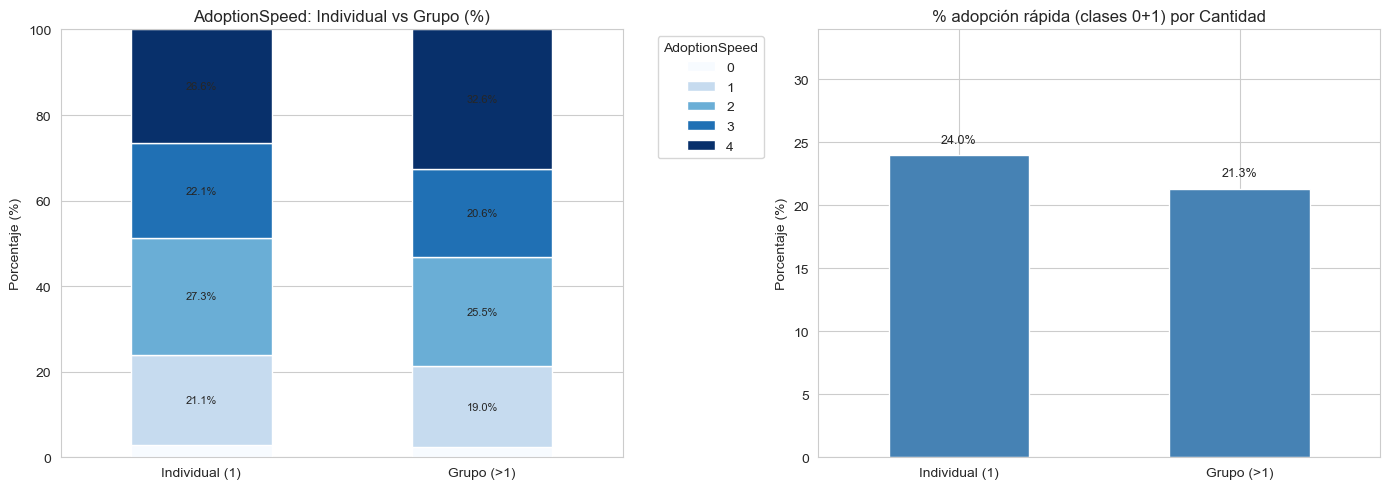

In [ ]:
# 1. Crear variable dicotómica
df['IsGroup'] = (df['Quantity'] > 1).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cross = df.groupby(['IsGroup', 'AdoptionSpeed']).size().unstack(fill_value=0)
cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100
cross_pct.index = ['Individual (1)', 'Grupo (>1)']

ax0 = cross_pct.plot(kind='bar', stacked=True, ax=axes[0],
                     colormap='Blues', edgecolor='white')

for i, row in enumerate(cross_pct.values):
    acumulado = 0
    for val in row:
        if val > 3:
            ax0.text(i, acumulado + val/2, f'{val:.1f}%',
                     ha='center', va='center', fontsize=8)
        acumulado += val

axes[0].set_title('AdoptionSpeed: Individual vs Grupo (%)')
axes[0].set_ylabel('Porcentaje (%)')
axes[0].set_ylim(0, 100)
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='AdoptionSpeed', bbox_to_anchor=(1.05, 1), loc='upper left')

rate = df.groupby('IsGroup')['AdoptionSpeed'].apply(
    lambda x: (x.isin([0, 1])).mean() * 100
)
rate.index = ['Individual (1)', 'Grupo (>1)']

ax1 = rate.plot(kind='bar', ax=axes[1],
                color='steelblue', edgecolor='white')

for i, val in enumerate(rate.values):
    ax1.text(i, val + 1, f'{val:.1f}%', ha='center', fontsize=9)

axes[1].set_title('% adopción rápida (clases 0+1) por Cantidad')
axes[1].set_ylabel('Porcentaje (%)')
axes[1].set_ylim(0, rate.max() + 10)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

Se observa una mayor proporción de adopción rápida en casos de un sólo animal, concentrándose más las adopciones lentas en las grupales.

#### Asociación categórica vs target mediante chi-cuadrado

In [ ]:
from scipy.stats import chi2_contingency

chi_results = []

for col in cat_cols:
    
    tmp = df[[col, "AdoptionSpeed"]].dropna()
    
    # Evitar variables con un solo nivel
    if tmp[col].nunique() < 2:
        continue
    
    table = pd.crosstab(tmp[col], tmp["AdoptionSpeed"])
    
    # Evitar tablas muy chicas o problemáticas
    if table.shape[0] < 2 or table.shape[1] < 2:
        continue
    
    chi2, pval, dof, expected = chi2_contingency(table)
    
    # Calcular V de Cramér (tamaño de efecto)
    n = table.sum().sum()
    r, k = table.shape
    cramers_v = np.sqrt(chi2 / (n * (min(r-1, k-1))))
    
    chi_results.append({
        "variable": col,
        "chi2": chi2,
        "p_value": pval,
        "cramers_v": cramers_v,
        "degrees_freedom": dof,
        "levels": tmp[col].nunique(),
        "n": n
    })

chi_df = pd.DataFrame(chi_results).sort_values("p_value")

chi_df

,variable,chi2,p_value,cramers_v,degrees_freedom,levels,n
5,Sterilized,794.393912,3.324333e-166,0.162764,8,3,14993
3,Vaccinated,283.425910,1.380857e-56,0.097221,8,3,14993
9,HasPhoto,247.851309,1.889834e-52,0.128573,4,2,14993
2,FurLength,177.259035,3.873065e-34,0.076886,8,3,14993
4,Dewormed,147.856830,5.486807e-28,0.070220,8,3,14993
1,MaturitySize,152.760409,1.560309e-26,0.058277,12,4,14993
0,Gender,77.100026,1.871014e-13,0.050707,8,3,14993
8,IsMixed,43.125324,9.746421e-09,0.053632,4,2,14993
7,HasName,38.479055,8.924413e-08,0.050660,4,2,14993
10,HasVideo,25.673645,3.681926e-05,0.041381,4,2,14993


Todas las variables muestran asociación significativa (p < 0.05), explicada probablemente por el tamaño muestral. Los valores de V de Cramér indican que las asociaciones son en general débiles, siendo las más relevantes si el animal está esterilizado (Sterilized), tiene foto (HasPhoto) y está vacunado (Vaccinated).

---
## 4. Análisis Multivariado

### 4.1 Matriz de correlación de Spearman (variables numéricas)

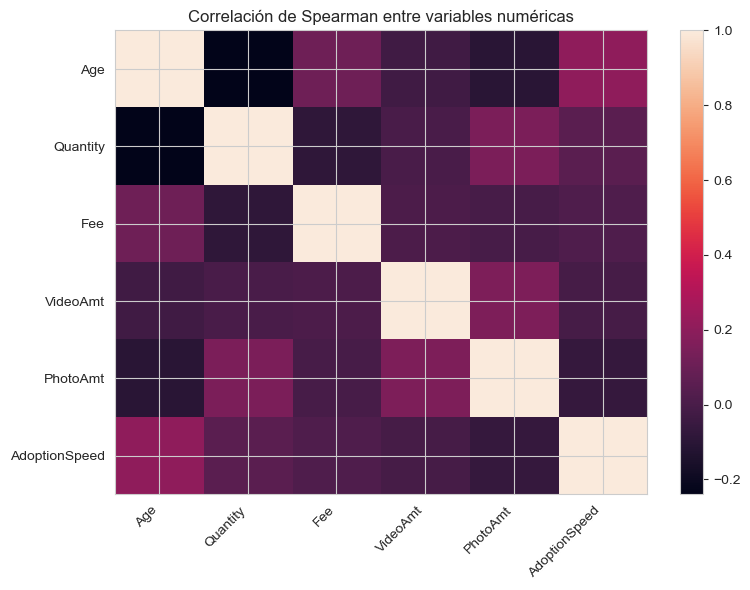

,Age,Quantity,Fee,VideoAmt,PhotoAmt,AdoptionSpeed
Age,1.000000,-0.239861,0.112785,-0.030555,-0.101358,0.209529
Quantity,-0.239861,1.000000,-0.080122,-0.000007,0.148199,0.053489
Fee,0.112785,-0.080122,1.000000,0.008566,-0.004158,0.018479
VideoAmt,-0.030555,-0.000007,0.008566,1.000000,0.153238,-0.011440
PhotoAmt,-0.101358,0.148199,-0.004158,0.153238,1.000000,-0.061919
AdoptionSpeed,0.209529,0.053489,0.018479,-0.011440,-0.061919,1.000000


In [ ]:
df['AdoptionSpeed'] = pd.to_numeric(df['AdoptionSpeed'], errors='coerce')

num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

if 'AdoptionSpeed' not in num_cols:
    num_cols.append('AdoptionSpeed')

df_num = df[num_cols].copy()

corr = df_num.corr(method='spearman')

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, aspect='auto')

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.index)

ax.set_title('Correlación de Spearman entre variables numéricas')
fig.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

corr

*  La variable que presenta mayor asociación con la velocidad de adopción es la edad, indicando que los animales más grandes tienden a ser adoptados más lentamente.
* La edad también está relacionada con la cantidad de animales por publicación: los animales más jóvenes suelen aparecer en publicaciones con mayor número de individuos. 
* El resto de las variables analizadas muestran asociaciones débiles.

### 4.2 Tipo de animal × Edad × AdoptionSpeed

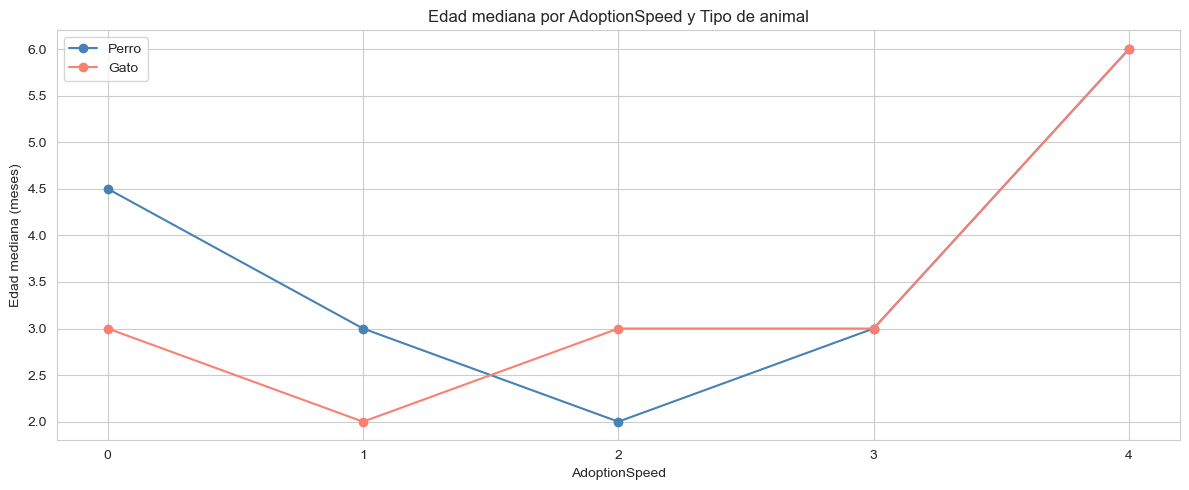

In [ ]:
plt.figure(figsize=(12, 5))
for tipo, color in [('Perro', 'steelblue'), ('Gato', 'salmon')]:
    subset = df[df['Type'] == tipo]
    mean_age = subset.groupby('AdoptionSpeed')['Age'].median()
    plt.plot(mean_age.index, mean_age.values, marker='o', label=tipo, color=color)

plt.title('Edad mediana por AdoptionSpeed y Tipo de animal')
plt.xlabel('AdoptionSpeed')
plt.ylabel('Edad mediana (meses)')
plt.xticks([0, 1, 2, 3, 4])
plt.legend()
plt.tight_layout()
plt.show()

La edad impacta en la adopción en ambos tipos de animales, pero el efecto es más pronunciado en gatos, donde los de mayor edad presentan una mayor probabilidad de no ser adoptados.

### 4.3 Tipo × Variables de salud × AdoptionSpeed

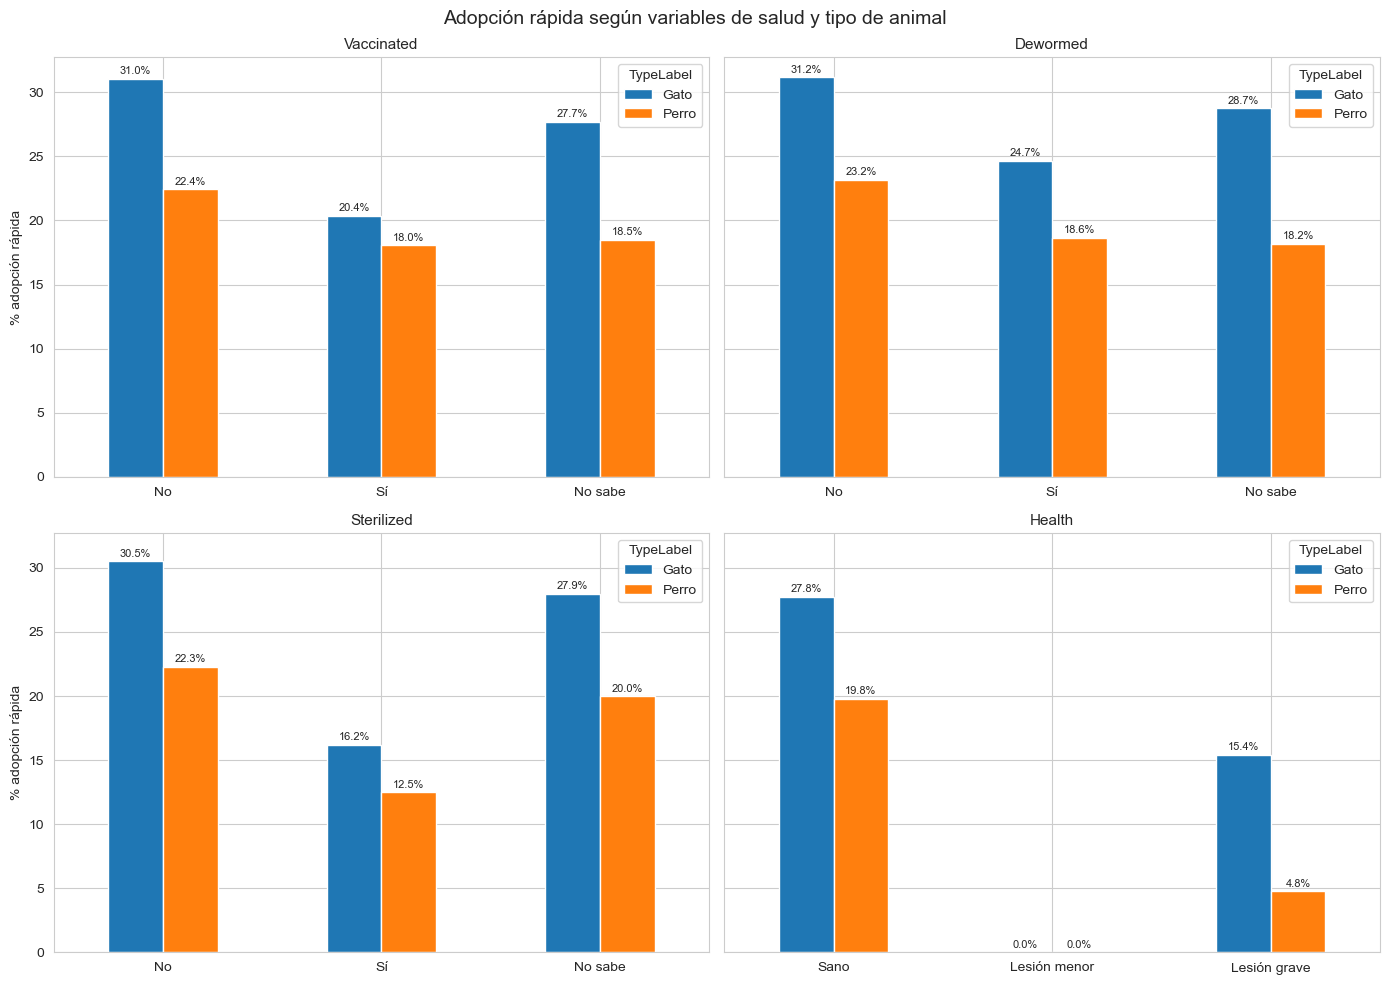

In [ ]:
import matplotlib.pyplot as plt

# Variable binaria
df['AdoptFast'] = df['AdoptionSpeed'].isin([0, 1]).astype(int)

# Tipo de animal
df['TypeLabel'] = df['Type'].astype(str).str.strip()

# Recodificación
health_vars = {
    'Vaccinated': {1: 'No', 2: 'Sí', 3: 'No sabe'},
    'Dewormed': {1: 'No', 2: 'Sí', 3: 'No sabe'},
    'Sterilized': {1: 'No', 2: 'Sí', 3: 'No sabe'},
    'Health': {1: 'Sano', 2: 'Lesión menor', 3: 'Lesión grave'}
}

# 👉 Grid 2x2
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)
axes = axes.flatten()  # para iterar fácil

for i, (var, mapping) in enumerate(health_vars.items()):
    
    label_col = var + 'Label'
    
    if pd.api.types.is_numeric_dtype(df[var]):
        df[label_col] = df[var].map(mapping)
    else:
        df[label_col] = df[var].astype(str).str.strip()
    
    plot_df = (
        df[['TypeLabel', label_col, 'AdoptFast']]
        .dropna()
        .groupby([label_col, 'TypeLabel'], as_index=False)['AdoptFast']
        .mean()
    )
    
    plot_df['AdoptFast'] *= 100
    
    pivot_df = plot_df.pivot(index=label_col, columns='TypeLabel', values='AdoptFast')
    
    # Orden lógico
    if var in ['Vaccinated', 'Dewormed', 'Sterilized']:
        pivot_df = pivot_df.reindex(['No', 'Sí', 'No sabe'])
    else:
        pivot_df = pivot_df.reindex(['Sano', 'Lesión menor', 'Lesión grave'])
    
    ax = axes[i]
    pivot_df.plot(kind='bar', ax=ax, edgecolor='white')
    
    ax.set_title(var, fontsize=11)
    ax.set_xlabel('')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    
    # Solo primera columna con eje Y
    if i % 2 == 0:
        ax.set_ylabel('% adopción rápida')
    else:
        ax.set_ylabel('')
    
    # Etiquetas
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', padding=2, fontsize=8)

# 👉 Título general
plt.suptitle('Adopción rápida según variables de salud y tipo de animal', fontsize=14)

plt.tight_layout()
plt.show()

---
## 5. Conclusiones preliminares

### Hallazgos principales

**Sobre el target:**
- Las clases 2 y 3 (adopción en 1er mes y 2do-3er mes) son las más frecuentes, lo que confirma un patrón de adopción levemente tardío.
- La adopción inmediata (clase 0) es poco común, por lo que las publicaciones deben enfocarse en mejorar visibilidad y contenido para acelerar la respuesta.

**Factores individuales clave:**
- **Tipo**: los gatos se adoptan más rápido que los perros; esta diferencia sugiere incluir interacciones con edad y fee en modelos predictivos.
- **Edad**: es el predictor individual más fuerte. Los animales más jóvenes tienen mayor probabilidad de adopción rápida, de modo que la edad debe tratarse con cuidado en el modelado.
- **Fotos**: mayor número de fotos se asocia con adopción rápida, reforzando la importancia de presentar bien la mascota.
- **Fee**: el impacto es mixto: en gatos tiende a penalizar, en perros puede asociarse a adopciones más rápidas. El fee actúa como proxy de calidad percibida y tipo de animal.
- **Salud**: animales con problemas graves presentan menor adopción rápida, lo que evidencia la relevancia de la condición médica en la decisión del adoptante.

**Análisis de texto en Description:**
- La nube de palabras revela que términos como “juguetón”, “cariñoso”, “familia”, “activo” y “saludable” aparecen con frecuencia y pueden ser señal de descripciones más atractivas.
- Esto sugiere que la calidad del texto y las palabras elegidas en la publicación pueden ser una dimensión adicional útil para predecir AdoptionSpeed.

**Contexto geográfico y socioeconómico:**
- Algunos estados muestran diferencias claras en adopción rápida, y variables como HDI, población, mortalidad infantil y esperanza de vida ayudan a definir perfiles regionales distintos.
- El análisis multivariante con PCA y clustering permite identificar grupos de estados con perfiles socioeconómicos similares y diferentes tasas de adopción rápida.

**Recomendaciones generales:**
- Incorporar variables de contexto local (estado y características socioeconómicas) junto con datos individuales mejora la interpretación y el rendimiento del modelo.
- La descripción de la publicación debería considerarse para enriquecer el modelo, ya que el contenido textual aporta señales adicionales de la presentación del animal.
- Para futuras versiones, conviene explorar modelos ordinales y técnicas de NLP que incluyan palabras clave de la descripción y perfiles de estado.

### 3.9 Estado geográfico: características socioeconómicas y adopción

Añadimos una tabla de variables por estado para explorar si factores como el HDI, la población, mortalidad infantil, esperanza de vida y composición étnica se relacionan con la velocidad de adopción.

In [ ]:
from scipy.stats import spearmanr, ttest_ind
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Información por estado
state_features = pd.DataFrame([
    ['Johor', 0.826, 7.0, 3.8, 0.4, 74.6, 59.5, 49.1],
    ['Kedah', 0.809, 8.8, 2.1, 0.4, 72.7, 80.7, 50.1],
    ['Kelantan', 0.779, 6.9, 1.8, 0.4, 72.0, 95.5, 50.1],
    ['Kuala Lumpur', 0.869, 31.4, 2.1, 0.3, 76.5, 47.6, 46.0],
    ['Labuan', 0.787, 4.9, 0.1, 0.4, 76.1, 28.4, 48.7],
    ['Melaka', 0.836, 6.7, 1.0, 0.4, 73.8, 71.6, 47.1],
    ['Negeri Sembilan', 0.830, 7.5, 1.2, 0.4, 73.7, 62.4, 48.0],
    ['Pahang', 0.806, 6.7, 1.7, 0.6, 72.6, 75.7, 46.7],
    ['Perak', 0.817, 9.7, 2.6, 0.4, 73.3, 59.0, 47.7],
    ['Pulau Pinang', 0.846, 7.7, 1.8, 0.3, 74.4, 45.4, 48.7],
    ['Sabah', 0.712, 6.0, 3.7, 0.6, 74.1, 12.1, 47.8],
    ['Sarawak', 0.746, 8.3, 2.5, 0.5, 74.9, 25.2, 48.4],
    ['Selangor', 0.865, 7.7, 7.4, 0.3, 78.1, 60.3, 46.6],
    ['Terengganu', 0.801, 5.9, 1.2, 0.6, 71.2, 97.4, 48.6]
], columns=[
    'State', 'HDI', 'perc_aging_pop', 'million_population', 'toddler_mort_rate',
    'life_expectancy', 'perc_ethnic_malay', 'perc_women'
])

# Unir información estatal al dataset principal
state_enriched = df.merge(state_features, on='State', how='left')

# Verificar coincidencias de nombres de estado
missing_states = set(df['State'].dropna().unique()) - set(state_features['State'].unique())
print('Estados sin datos adicionales:', missing_states)

# Resumen por estado
state_summary = (
    state_enriched
    .groupby('State', observed=False)
    .agg(
        n=('AdoptionSpeed', 'size'),
        mean_speed=('AdoptionSpeed', 'mean'),
        fast_rate=('AdoptionSpeed', lambda x: np.mean(x.isin([0, 1])) * 100),
        median_age=('Age', 'median'),
        avg_photos=('PhotoAmt', 'mean'),
        pct_vaccinated=('Vaccinated', lambda x: np.mean(x == 1) * 100),
        HDI=('HDI', 'first'),
        perc_aging_pop=('perc_aging_pop', 'first'),
        million_population=('million_population', 'first'),
        toddler_mort_rate=('toddler_mort_rate', 'first'),
        life_expectancy=('life_expectancy', 'first'),
        perc_ethnic_malay=('perc_ethnic_malay', 'first'),
        perc_women=('perc_women', 'first')
    )
    .reset_index()
)

state_summary = state_summary.sort_values('mean_speed')
state_summary[['State', 'n', 'mean_speed', 'fast_rate', 'HDI']].head(14)

Estados sin datos adicionales: set()


,State,n,mean_speed,fast_rate,HDI
7,Pahang,85,2.317647,37.647059,0.806
2,Kelantan,15,2.400000,33.333333,0.779
0,Johor,507,2.410256,26.824458,0.826
12,Selangor,8714,2.452031,24.363094,0.865
3,Kuala Lumpur,3845,2.540182,24.083225,0.869
10,Sabah,22,2.545455,31.818182,0.712
13,Terengganu,26,2.576923,34.615385,0.801
1,Kedah,110,2.681818,15.454545,0.809
9,Pulau Pinang,843,2.781732,15.421115,0.846
8,Perak,420,2.821429,12.142857,0.817


In [ ]:
# Correlaciones entre métricas de adopción y características estatales
state_numeric = state_summary[
    ['mean_speed', 'fast_rate', 'HDI', 'perc_aging_pop', 'million_population',
     'toddler_mort_rate', 'life_expectancy', 'perc_ethnic_malay', 'perc_women']
].copy()

corr_spearman = state_numeric.corr(method='spearman')['mean_speed'].sort_values(ascending=False)
print('Correlación de Spearman con mean_speed:')
print(corr_spearman)

corr_pearson = state_numeric.corr(method='pearson')['mean_speed'].sort_values(ascending=False)
print('\nCorrelación de Pearson con mean_speed:')
print(corr_pearson)

# Pruebas de hipótesis para medir significancia de la relación con mean_speed
print('\nPruebas de hipótesis por variable de estado:')
for feature in ['HDI', 'perc_aging_pop', 'million_population', 'toddler_mort_rate',
                'life_expectancy', 'perc_ethnic_malay', 'perc_women']:
    x = state_summary['mean_speed']
    y = state_summary[feature]
    rho, pval = spearmanr(x, y, nan_policy='omit')
    low = state_summary[state_summary[feature] <= state_summary[feature].median()]['mean_speed']
    high = state_summary[state_summary[feature] > state_summary[feature].median()]['mean_speed']
    tstat, p_t = ttest_ind(low, high, equal_var=False, nan_policy='omit')
    print(f"{feature}: Spearman rho={rho:.3f}, p={pval:.3f}; t-test p={p_t:.3f}")

Correlación de Spearman con mean_speed:
mean_speed            1.000000
life_expectancy       0.191209
perc_aging_pop        0.061674
perc_women            0.044053
toddler_mort_rate    -0.011854
HDI                  -0.054945
million_population   -0.363839
perc_ethnic_malay    -0.367033
fast_rate            -0.789011
Name: mean_speed, dtype: float64

Correlación de Pearson con mean_speed:
mean_speed            1.000000
life_expectancy       0.131427
perc_women            0.061326
toddler_mort_rate    -0.092524
perc_aging_pop       -0.123978
HDI                  -0.185744
million_population   -0.385286
perc_ethnic_malay    -0.417361
fast_rate            -0.761251
Name: mean_speed, dtype: float64

Pruebas de hipótesis por variable de estado:
HDI: Spearman rho=-0.055, p=0.852; t-test p=0.939
perc_aging_pop: Spearman rho=0.062, p=0.834; t-test p=0.321
million_population: Spearman rho=-0.364, p=0.201; t-test p=0.842
toddler_mort_rate: Spearman rho=-0.012, p=0.968; t-test p=0.958
life_expect

Varianza explicada por PCA: [0.416, 0.233]


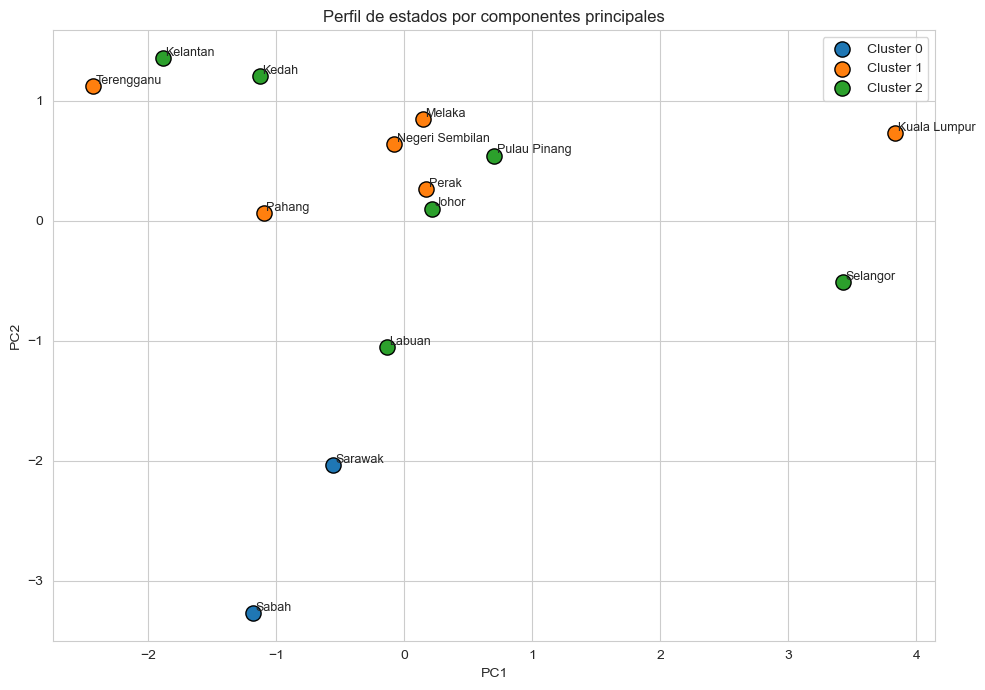

In [ ]:
# Análisis multivariante de perfiles de estado usando PCA y clustering
cluster_features = ['HDI', 'perc_aging_pop', 'million_population', 'toddler_mort_rate',
                    'life_expectancy', 'perc_ethnic_malay', 'perc_women']

X = state_summary[cluster_features].fillna(state_summary[cluster_features].mean())
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
state_summary[['PC1', 'PC2']] = pca.fit_transform(X_scaled)

kmeans = KMeans(n_clusters=3, random_state=42)
state_summary['cluster'] = kmeans.fit_predict(X_scaled)

# Mostrar los perfiles
print('Varianza explicada por PCA:', pca.explained_variance_ratio_.round(3).tolist())

fig, ax = plt.subplots(figsize=(10, 7))
for cluster in sorted(state_summary['cluster'].unique()):
    subset = state_summary[state_summary['cluster'] == cluster]
    ax.scatter(subset['PC1'], subset['PC2'], s=120, label=f'Cluster {cluster}', edgecolor='k')
    for _, row in subset.iterrows():
        ax.text(row['PC1'] + 0.02, row['PC2'] + 0.02, row['State'], fontsize=9)

ax.set_title('Perfil de estados por componentes principales')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Resumen de clusters y adopción
cluster_profile = (
    state_summary
    .groupby('cluster', observed=False)
    .agg(
        n_states=('State', 'size'),
        mean_speed=('mean_speed', 'mean'),
        fast_rate=('fast_rate', 'mean'),
        mean_HDI=('HDI', 'mean'),
        mean_life_expectancy=('life_expectancy', 'mean'),
        mean_million_population=('million_population', 'mean')
    )
    .round(3)
)

cluster_profile

,n_states,mean_speed,fast_rate,mean_HDI,mean_life_expectancy,mean_million_population
cluster,,,,,,
0,2,2.927,23.601,0.729,74.500,3.100
1,6,2.695,23.393,0.826,73.517,1.633
2,6,2.621,19.233,0.819,74.650,2.833


El análisis sugiere que algunos grupos de estados tienen perfiles socioeconómicos distintos y niveles diferentes de adopción rápida. Esto permite explorar si los factores del entorno local (urbanidad, nivel de vida, estructura demográfica) influyen en la velocidad de adopción y mejorar la interpretación conjunta con otras variables individuales.

---
### 4.4 Tipo × Fee × AdoptionSpeed

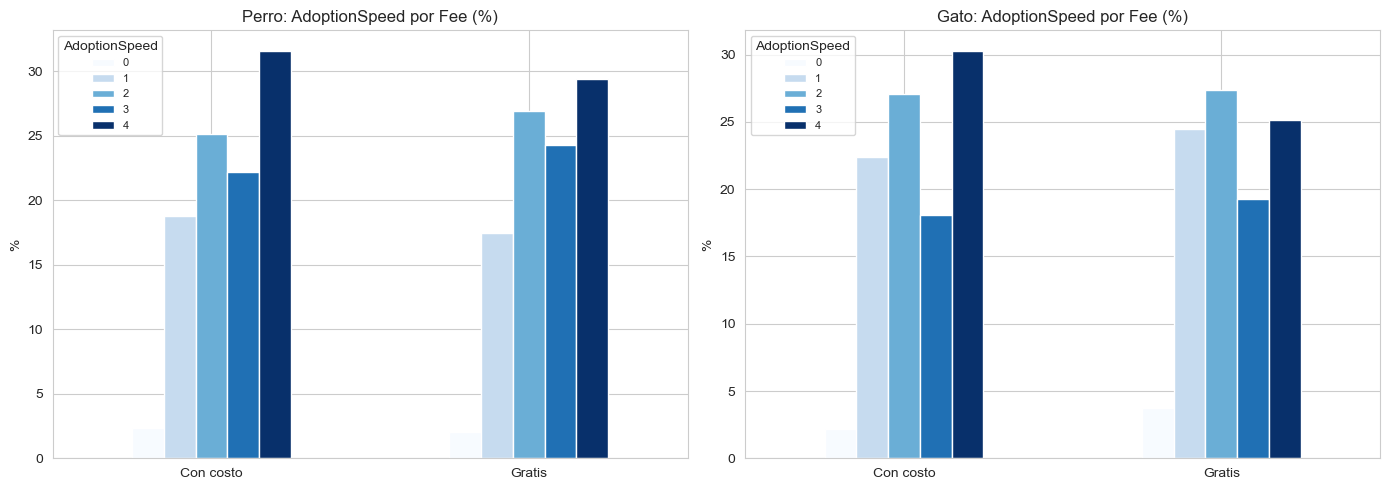

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, tipo in zip(axes, ['Perro', 'Gato']):
    subset = df[df['Type'] == tipo]
    cross = subset.groupby(['IsFree', 'AdoptionSpeed']).size().unstack(fill_value=0)
    cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100
    cross_pct.index = ['Con costo', 'Gratis']
    cross_pct.plot(kind='bar', ax=ax, colormap='Blues', edgecolor='white')
    ax.set_title(f'{tipo}: AdoptionSpeed por Fee (%)')
    ax.tick_params(axis='x', rotation=0)
    ax.set_ylabel('%')
    ax.legend(title='AdoptionSpeed', fontsize=8)

plt.tight_layout()
plt.show()

C:\Users\julia\AppData\Local\Temp\ipykernel_40120\4203173170.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['FeeGroup', 'TypeLabel'], as_index=False)['AdoptFast']


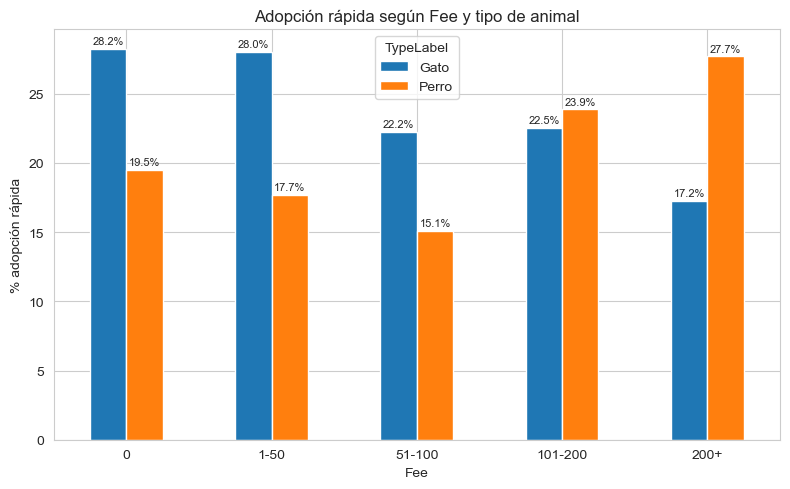

In [ ]:
# Variable binaria
df['AdoptFast'] = df['AdoptionSpeed'].isin([0, 1]).astype(int)

# Tipo de animal
df['TypeLabel'] = df['Type'].astype(str).str.strip()

# Crear categorías de Fee
df['FeeGroup'] = pd.cut(
    df['Fee'],
    bins=[-1, 0, 50, 100, 200, df['Fee'].max()],
    labels=['0', '1-50', '51-100', '101-200', '200+']
)

# Calcular % de adopción rápida
plot_df = (
    df[['FeeGroup', 'TypeLabel', 'AdoptFast']]
    .dropna()
    .groupby(['FeeGroup', 'TypeLabel'], as_index=False)['AdoptFast']
    .mean()
)

plot_df['AdoptFast'] *= 100

pivot_df = plot_df.pivot(index='FeeGroup', columns='TypeLabel', values='AdoptFast')

# Gráfico
ax = pivot_df.plot(kind='bar', figsize=(8, 5), edgecolor='white')

ax.set_title('Adopción rápida según Fee y tipo de animal')
ax.set_xlabel('Fee')
ax.set_ylabel('% adopción rápida')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=2, fontsize=8)

plt.tight_layout()
plt.show()

En el caso de los gatos, sucede que a medida que aumenta el valor de la adopción, disminuyen las adopciones. Sin embargos, en los perros se observa incluso mayores niveles de adopción rápida en los rangos de fee más altos. Esto podría estar relacionado con otras características del animal, como la raza. 

### 4.5 Fotos × Tipo × AdoptionSpeed

C:\Users\julia\AppData\Local\Temp\ipykernel_40120\905222417.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot = subset.groupby('PhotoGroup')['AdoptionSpeed'].mean().reset_index()
C:\Users\julia\AppData\Local\Temp\ipykernel_40120\905222417.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot = subset.groupby('PhotoGroup')['AdoptionSpeed'].mean().reset_index()


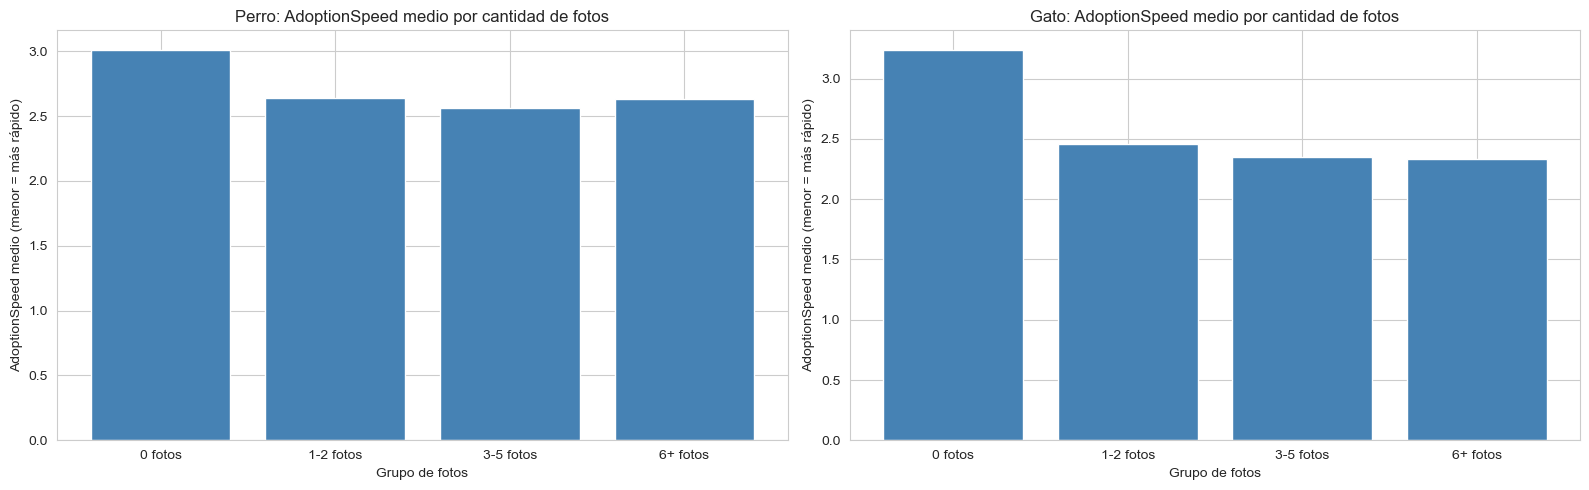

In [ ]:
# Categorizar cantidad de fotos
df['PhotoGroup'] = pd.cut(df['PhotoAmt'].fillna(0),
                           bins=[-1, 0, 2, 5, 100],
                           labels=['0 fotos', '1-2 fotos', '3-5 fotos', '6+ fotos'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, tipo in zip(axes, ['Perro', 'Gato']):
    subset = df[df['Type'] == tipo]
    pivot = subset.groupby('PhotoGroup')['AdoptionSpeed'].mean().reset_index()
    ax.bar(pivot['PhotoGroup'].astype(str), pivot['AdoptionSpeed'], color='steelblue')
    ax.set_title(f'{tipo}: AdoptionSpeed medio por cantidad de fotos')
    ax.set_xlabel('Grupo de fotos')
    ax.set_ylabel('AdoptionSpeed medio (menor = más rápido)')

plt.tight_layout()
plt.show()

### 4.6 Pairplot: variables numéricas clave coloreadas por AdoptionSpeed

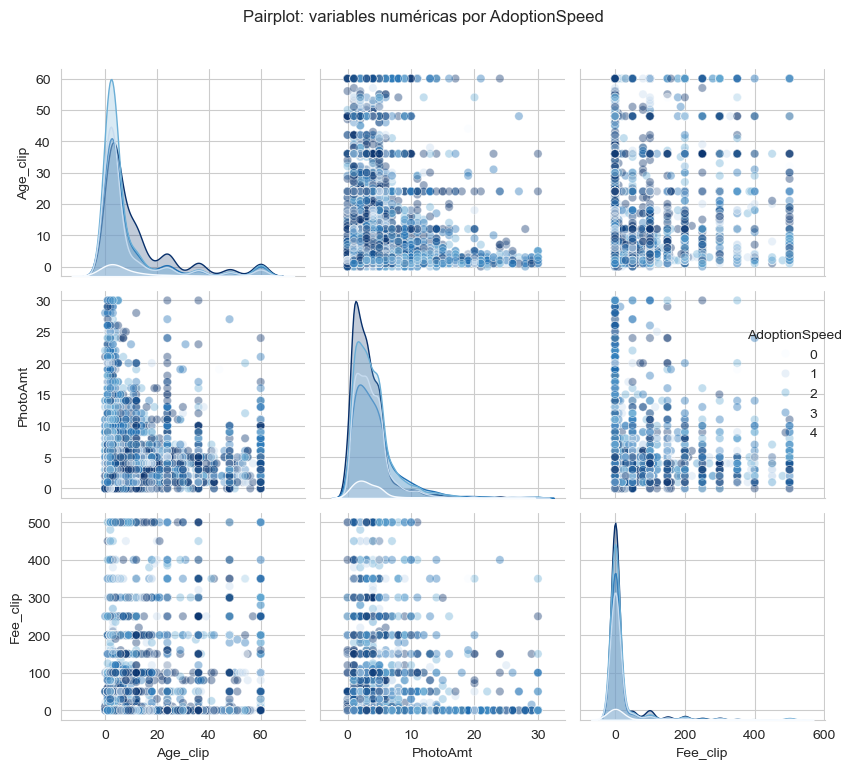

In [ ]:
pair_cols = ['Age', 'PhotoAmt', 'Fee', 'AdoptionSpeed']
pair_df = df[pair_cols].copy()
pair_df['PhotoAmt'] = pair_df['PhotoAmt'].fillna(0)
pair_df['Fee_clip'] = pair_df['Fee'].clip(upper=500)
pair_df['Age_clip'] = pair_df['Age'].clip(upper=60)

g = sns.pairplot(pair_df[['Age_clip', 'PhotoAmt', 'Fee_clip', 'AdoptionSpeed']],
                 hue='AdoptionSpeed', palette='Blues', plot_kws={'alpha': 0.4},
                 diag_kind='kde')
g.fig.suptitle('Pairplot: variables numéricas por AdoptionSpeed', y=1.02)
plt.tight_layout()
plt.show()

### 4.7 Heatmap: tasa de adopción rápida por Estado y Tipo

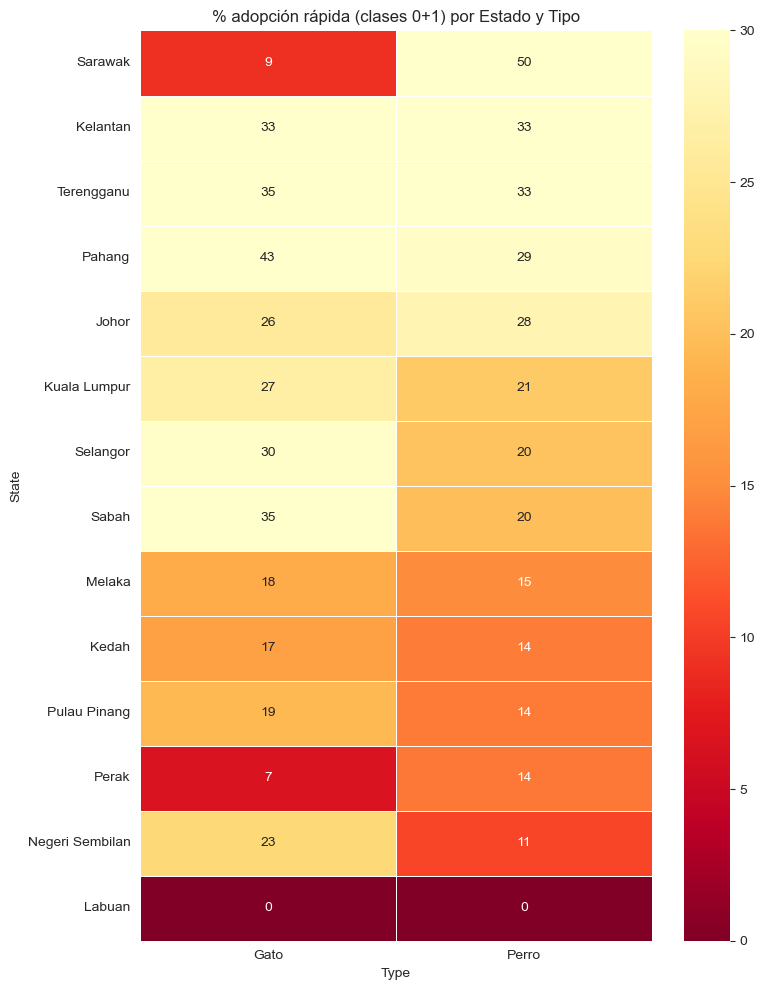

In [ ]:
pivot_state = df.groupby(['State', 'Type'])['AdoptionSpeed'].apply(
    lambda x: (x.isin([0, 1])).mean() * 100
).unstack()

plt.figure(figsize=(8, 10))
sns.heatmap(pivot_state.sort_values('Perro', ascending=False),
            annot=True, fmt='.0f', cmap='YlOrRd_r',
            linewidths=0.5, vmin=0, vmax=30)
plt.title('% adopción rápida (clases 0+1) por Estado y Tipo')
plt.tight_layout()
plt.show()

### 4.8 Estado de salud x Edad x 

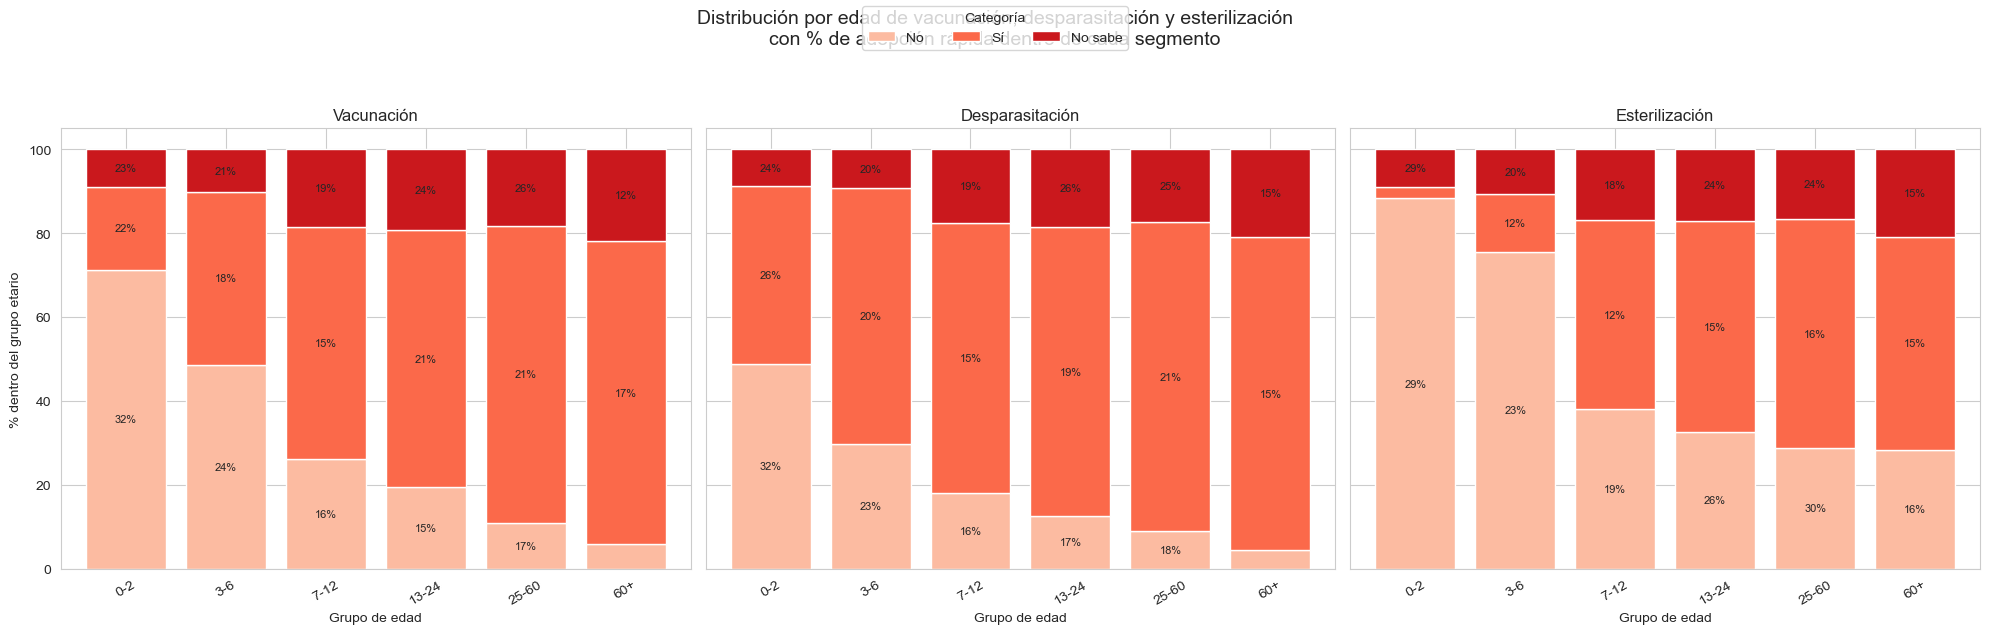

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_plot = df.copy()

# adopción rápida
df_plot["AdoptFast"] = df_plot["AdoptionSpeed"].isin([0, 1]).astype(int)

# grupos de edad
bins = [-1, 2, 6, 12, 24, 60, 300]
labels = ["0-2", "3-6", "7-12", "13-24", "25-60", "60+"]
df_plot["AgeGroup"] = pd.cut(df_plot["Age"], bins=bins, labels=labels)

# usar columnas originales
vars_plot = {
    "Vaccinated": "Vacunación",
    "Dewormed": "Desparasitación",
    "Sterilized": "Esterilización"
}

order_cat = ["No", "Sí", "No sabe"]
palette = sns.color_palette("Reds", n_colors=3)

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

for ax, (var, title) in zip(axes, vars_plot.items()):

    # quedarnos solo con categorías válidas
    subset = df_plot[df_plot[var].isin(order_cat)].copy()

    # composición dentro de cada grupo etario
    tab = pd.crosstab(
        subset["AgeGroup"],
        subset[var],
        normalize="index"
    ) * 100

    tab = tab.reindex(index=labels, columns=order_cat)

    # eliminar grupos vacíos para evitar el error
    tab = tab.dropna(how="all")

    if tab.empty:
        ax.set_title(title)
        ax.text(0.5, 0.5, "Sin datos", ha="center", va="center")
        ax.axis("off")
        continue

    tab.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        color=palette,
        edgecolor="white",
        width=0.8
    )

    # % adopción rápida por grupo etario y categoría
    adopt_tab = (
        subset.groupby(["AgeGroup", var], observed=False)["AdoptFast"]
        .mean()
        .mul(100)
        .reset_index()
    )

    # etiquetas dentro de cada segmento
    cumulative = pd.Series(0, index=tab.index)

    for cat in order_cat:
        if cat not in tab.columns:
            continue

        vals = tab[cat].fillna(0)

        for i, age_group in enumerate(tab.index):
            height = vals.loc[age_group]
            if height < 8:
                continue

            rate_row = adopt_tab[
                (adopt_tab["AgeGroup"] == age_group) &
                (adopt_tab[var] == cat)
            ]

            if not rate_row.empty:
                rate = rate_row["AdoptFast"].values[0]
                y = cumulative.loc[age_group] + height / 2
                ax.text(
                    i, y,
                    f"{rate:.0f}%",
                    ha="center", va="center",
                    fontsize=8
                )

        cumulative += vals

    ax.set_title(title)
    ax.set_xlabel("Grupo de edad")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30)

    if ax == axes[0]:
        ax.set_ylabel("% dentro del grupo etario")
    else:
        ax.set_ylabel("")

    if ax.legend_ is not None:
        ax.legend_.remove()

handles, labels_leg = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_leg, title="Categoría", loc="upper center", ncol=3)

plt.suptitle(
    "Distribución por edad de vacunación, desparasitación y esterilización\ncon % de adopción rápida dentro de cada segmento",
    fontsize=14,
    y=1.05
)

plt.tight_layout()
plt.show()

Se observa que la proporción de animales vacunados, desparasitados y esterilizados aumenta sistemáticamente con la edad. Dado que la edad también se asocia con la probabilidad de adopción rápida, estas variables podrían estar funcionando como indicadores indirectos de la edad, actuando como variables de confusión en el análisis de adopción.

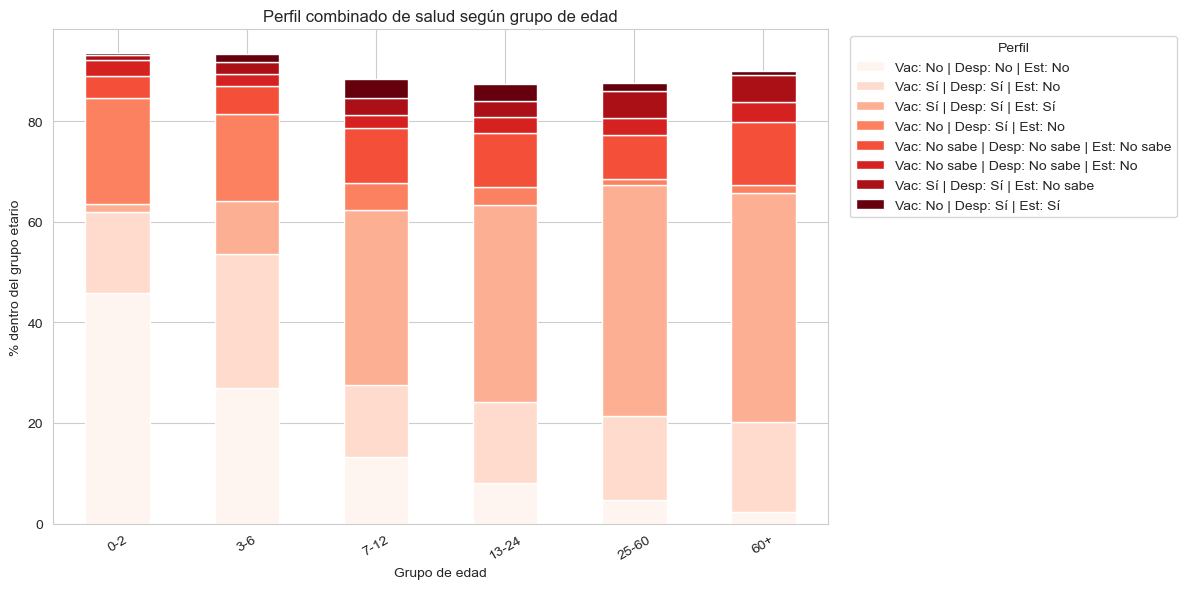

In [ ]:
df_plot = df.copy()

# adopción rápida
df_plot["AdoptFast"] = df_plot["AdoptionSpeed"].isin([0, 1]).astype(int)

# grupos de edad
bins = [-1, 2, 6, 12, 24, 60, 300]
labels_age = ["0-2", "3-6", "7-12", "13-24", "25-60", "60+"]
df_plot["AgeGroup"] = pd.cut(df_plot["Age"], bins=bins, labels=labels_age)

# asegurarnos de trabajar solo con categorías interpretables
order_cat = ["No", "Sí", "No sabe"]

subset = df_plot[
    df_plot["Vaccinated"].isin(order_cat) &
    df_plot["Dewormed"].isin(order_cat) &
    df_plot["Sterilized"].isin(order_cat)
].copy()

# variable combinada
subset["HealthProfile"] = (
    "Vac: " + subset["Vaccinated"] +
    " | Desp: " + subset["Dewormed"] +
    " | Est: " + subset["Sterilized"]
)

tab = pd.crosstab(
    subset["AgeGroup"],
    subset["HealthProfile"],
    normalize="index"
) * 100

# quedarnos con los perfiles más frecuentes para no saturar
top_profiles = subset["HealthProfile"].value_counts().head(8).index
tab = tab[top_profiles]

fig, ax = plt.subplots(figsize=(12, 6))
tab.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    colormap="Reds",
    edgecolor="white"
)

ax.set_title("Perfil combinado de salud según grupo de edad")
ax.set_xlabel("Grupo de edad")
ax.set_ylabel("% dentro del grupo etario")
ax.tick_params(axis="x", rotation=30)
ax.legend(title="Perfil", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

Se observa una asociación entre el grupo etario y el estado sanitario de los animales. 
* En los grupos más jóvenes predominan perfiles con ausencia de cualquier intervenciones (> 40) o de una o dos de ellas.
* A medida que aumenta la edad crece la proporción de animales vacunados, desparasitados y esterilizados.

In [ ]:
from scipy.stats import chi2_contingency

samples = []

for _, group in subset.groupby("AgeGroup", observed=False):
    samples.append(group.sample(n=min(len(group), 1000), random_state=42))

sample = pd.concat(samples).reset_index(drop=True)

table = pd.crosstab(sample["AgeGroup"], sample["HealthProfile"])
chi2, p, dof, expected = chi2_contingency(table)

n = table.to_numpy().sum()
cramer_v = np.sqrt(chi2 / (n * (min(table.shape) - 1)))

print(f"Chi2 = {chi2:.2f}")
print(f"p-value = {p:.4e}")
print(f"Cramér's V = {cramer_v:.3f}")

Chi2 = 1968.09
p-value = 0.0000e+00
Cramér's V = 0.270


Existe una asociación estadísticamente significativa entre el grupo etario y el perfil combinado de salud.

---
## 5. Conclusiones preliminares

### Hallazgos principales

**Sobre el target:**
- Las clases 2 y 3 (adopción en 1er mes o en 2do-3er mes) son las más frecuentes. La distribución no es uniforme.
- Solo una pequeña proporción se adopta el mismo día (clase 0).

**Variables más relevantes para el modelo:**
- **Tipo**: introduce diferencias en la adopción. Los gatos tienden a adoptarse más rápido que los perros. Pueden evaluarse interacciones (especialmente con Fee y Edad).
- **Edad**: es una de las variables influyentes en la adopción: los animales más jóvenes presentan mayor probabilidad de adopción rápida. Puede modelarse como continua, aunque su distribución sesgada sugiere evaluar transformaciones o discretización.
- **Fotos**: la presencia y cantidad de fotos se asocia positivamente con la adopción rápida, posiblemente reflejando mayor visibilidad o calidad de publicación. Puede capturar comportamiento del rescatista más que del animal.
- **Fee**: el efecto del costo no es homogéneo. En gatos, a mayor costo, menor adopción. En perros, fees altos pueden asociarse a mayor adopción. Esto sugiere que el fee actúa como proxy de características del animal (raza, edad).
- **Vacunación / Esterilización / Desparasitación**: variables están fuertemente asociadas con la edad (los animales más jóvenes tienden a no haber recibido estos cuidados). Su relación con la adopción puede ser espuria si no se ajusta por edad. 
- **Estado de salud**: presenta una relación consistente con la adopción: animales con problemas graves muestran menor probabilidad de adopción rápida.
- **Nombre**: se observa una asociación leve con la adopción, posiblemente vinculada a una mayor “humanización” del animal o mejor presentación.
- **Estado geográfico**: existen diferencias regionales relevantes en la velocidad de adopción, lo que sugiere heterogeneidad en la oferta/demanda o en las dinámicas locales.

In [ ]:
# FEATURE ENGINEERING: variables derivadas y transformaciones ordenadas

# 1. Perfil combinado de salud
health_map = {
    'Sí': 1,
    'No': 0,
    'No sabe': 0,
    'No especif.': 0
}
df['HealthScore'] = (
    df['Vaccinated'].map(health_map).fillna(0)
    + df['Dewormed'].map(health_map).fillna(0)
    + df['Sterilized'].map(health_map).fillna(0)
    + df['Health'].map({
        'Sano': 1,
        'Lesión leve': 0.5,
        'Lesión grave': 0,
        'No especif.': 0
    }).fillna(0)
)
df['HealthProfile'] = pd.cut(
    df['HealthScore'],
    bins=[-0.1, 0.5, 1.5, 2.5, 4.0],
    labels=['Muy Bajo', 'Bajo', 'Medio', 'Alto']
).astype(str)

# 2. Fee en rangos y flag de gratuito
fee_bins = [-0.1, 0.0, 100.0, 300.0, 600.0, df['Fee'].max()]
fee_labels = ['Gratis', 'Bajo', 'Medio', 'Alto', 'Muy Alto']
df['FeeRange'] = pd.cut(df['Fee'].fillna(0), bins=fee_bins, labels=fee_labels)
df['IsFree'] = (df['Fee'] == 0).astype(int)

# 3. HasDescription y longitud del texto
if 'HasDescription' not in df.columns:
    df['HasDescription'] = df['Description'].notna().astype(int)

df['DescriptionWordCount'] = df['Description'].fillna('').apply(lambda x: len(x.split()))

df['DescriptionCharCount'] = df['Description'].fillna('').apply(len)

# 4. Frequencia de palabras clave en descripción
keywords = [
    'juguetón', 'cariñoso', 'sano', 'familia', 'activo', 'tranquilo',
    'amor', 'jugando', 'abierto', 'bueno', 'feliz', 'juego', 'educado'
]
text_lower = df['Description'].fillna('').str.lower()
for word in keywords:
    col = f'Desc_{word.replace("ñ", "n").replace(" ", "_")}'
    df[col] = text_lower.str.contains(fr'\b{re.escape(word)}\b', regex=True).astype(int)

# 5. Agrupaciones de alta cardinalidad
# Breed1 / Breed2: agrupar las razas menos frecuentes en 'Other'
for col in ['Breed1', 'Breed2']:
    top_freq = df[col].value_counts(normalize=True).cumsum().searchsorted(0.9)
    top_categories = df[col].value_counts().index[: top_freq + 1]
    df[f'{col}_grouped'] = df[col].where(df[col].isin(top_categories), 'Other')

# RescuerID: convertir en categorías frecuentes + Other
top_rescuers = df['RescuerID'].value_counts().index[:30]
df['RescuerID_grouped'] = df['RescuerID'].where(df['RescuerID'].isin(top_rescuers), 'Other')

# 6. Nombre: longitud y palabras clave especiales
name_keywords = ['rey', 'princesa', 'macho', 'nena', 'tigre', 'nala', 'luna', 'sol', 'reyecito', 'bella']
df['NameLength'] = df['Name'].fillna('').apply(lambda x: len(x.strip()))
df['NameWordCount'] = df['Name'].fillna('').apply(lambda x: len(x.split()))
for word in name_keywords:
    df[f'Name_has_{word}'] = df['Name'].fillna('').str.lower().str.contains(fr'\b{re.escape(word)}\b', regex=True).astype(int)

# 7. Estado: PCA/clustering de características de estado
state_features = pd.DataFrame([
    ['Johor', 0.826, 7.0, 3.8, 0.4, 74.6, 59.5, 49.1],
    ['Kedah', 0.809, 8.8, 2.1, 0.4, 72.7, 80.7, 50.1],
    ['Kelantan', 0.779, 6.9, 1.8, 0.4, 72.0, 95.5, 50.1],
    ['Kuala Lumpur', 0.869, 31.4, 2.1, 0.3, 76.5, 47.6, 46.0],
    ['Labuan', 0.787, 4.9, 0.1, 0.4, 76.1, 28.4, 48.7],
    ['Melaka', 0.836, 6.7, 1.0, 0.4, 73.8, 71.6, 47.1],
    ['Negeri Sembilan', 0.830, 7.5, 1.2, 0.4, 73.7, 62.4, 48.0],
    ['Pahang', 0.806, 6.7, 1.7, 0.6, 72.6, 75.7, 46.7],
    ['Perak', 0.817, 9.7, 2.6, 0.4, 73.3, 59.0, 47.7],
    ['Pulau Pinang', 0.846, 7.7, 1.8, 0.3, 74.4, 45.4, 48.7],
    ['Sabah', 0.712, 6.0, 3.7, 0.6, 74.1, 12.1, 47.8],
    ['Sarawak', 0.746, 8.3, 2.5, 0.5, 74.9, 25.2, 48.4],
    ['Selangor', 0.865, 7.7, 7.4, 0.3, 78.1, 60.3, 46.6],
    ['Terengganu', 0.801, 5.9, 1.2, 0.6, 71.2, 97.4, 48.6]
], columns=[
    'State', 'HDI', 'perc_aging_pop', 'million_population', 'toddler_mort_rate',
    'life_expectancy', 'perc_ethnic_malay', 'perc_women'
])

state_features = state_features.set_index('State')

state_merge = df[['State']].merge(state_features, left_on='State', right_index=True, how='left')
state_merge = state_merge.drop(columns=['State'])
state_merge = state_merge.fillna(state_merge.mean())

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

scaler = StandardScaler()
state_scaled = scaler.fit_transform(state_merge)

pca = PCA(n_components=2, random_state=42)
df[['State_PC1', 'State_PC2']] = pca.fit_transform(state_scaled)

kmeans = KMeans(n_clusters=3, random_state=42)
df['StateCluster'] = kmeans.fit_predict(state_scaled).astype(str)

# 8. Revisión rápida de los nuevos features
new_features = [
    'HealthProfile', 'HealthScore', 'FeeRange', 'IsFree', 'HasDescription',
    'DescriptionWordCount', 'DescriptionCharCount', 'RescuerID_grouped',
    'Breed1_grouped', 'Breed2_grouped', 'NameLength', 'NameWordCount',
    'State_PC1', 'State_PC2', 'StateCluster'
] + [f'Desc_{w.replace("ñ","n").replace(" ","_")}' for w in keywords]

print('Nuevas variables de feature engineering generadas:')
print(new_features)
print(df[new_features].head())

Nuevas variables de feature engineering generadas:
['HealthProfile', 'HealthScore', 'FeeRange', 'IsFree', 'HasDescription', 'DescriptionWordCount', 'DescriptionCharCount', 'RescuerID_grouped', 'Breed1_grouped', 'Breed2_grouped', 'NameLength', 'NameWordCount', 'State_PC1', 'State_PC2', 'StateCluster', 'Desc_juguetón', 'Desc_carinoso', 'Desc_sano', 'Desc_familia', 'Desc_activo', 'Desc_tranquilo', 'Desc_amor', 'Desc_jugando', 'Desc_abierto', 'Desc_bueno', 'Desc_feliz', 'Desc_juego', 'Desc_educado']
  HealthProfile  HealthScore FeeRange  IsFree  HasDescription  \
0          Bajo          1.0     Bajo       0               1   
1          Bajo          1.0   Gratis       1               1   
2          Alto          3.0   Gratis       1               1   
3          Alto          3.0    Medio       0               1   
4          Bajo          1.0   Gratis       1               1   

   DescriptionWordCount  DescriptionCharCount  \
0                    69                   359   
1         

### Modelo baseline: Random Forest con todas las variables disponibles

Construimos un pipeline simple que usa todas las variables estructuradas y las nuevas variables de texto creadas. Separamos conjunto de entrenamiento y prueba para evaluar un baseline inicial.

In [89]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Variables que no se usan como features
drop_cols = [
    'PetID', 'Description', 'Name', 'AdoptionSpeed',
    'AdoptFast', 'TypeLabel', 'PhotoGroup', 'FeeGroup'
]

feature_cols = [col for col in df.columns if col not in drop_cols]
X = df[feature_cols].copy()
y = df['AdoptionSpeed'].astype(int)

from pandas.api.types import is_categorical_dtype

# Codificar variables categóricas simples
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
for col in cat_cols:
    if is_categorical_dtype(X[col]):
        X[col] = X[col].cat.add_categories('missing').fillna('missing').astype(str)
    else:
        X[col] = X[col].fillna('missing').astype(str)

X = pd.get_dummies(X, columns=cat_cols, dummy_na=False)
X = X.fillna(-1)

# Separación de datos
test_size = 0.2
random_state = 42
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=test_size, random_state=random_state, stratify=y
)

print('Número de features usados:', X.shape[1])
print('Tamaño train:', X_train.shape, 'tamaño test:', X_test.shape)

# Entrenamiento de baseline
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=random_state,
    n_jobs=-1,
    class_weight='balanced'
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print('Accuracy test:', accuracy_score(y_test, y_pred))
print('\nReporte de clasificación:\n')
print(classification_report(y_test, y_pred, digits=3))

cm = confusion_matrix(y_test, y_pred)
print('Matriz de confusión:')
print(cm)

C:\Users\julia\AppData\Local\Temp\ipykernel_40120\1763087661.py:20: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if is_categorical_dtype(X[col]):
C:\Users\julia\AppData\Local\Temp\ipykernel_40120\1763087661.py:20: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if is_categorical_dtype(X[col]):
C:\Users\julia\AppData\Local\Temp\ipykernel_40120\1763087661.py:20: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if is_categorical_dtype(X[col]):
C:\Users\julia\AppData\Local\Temp\ipykernel_40120\1763087661.py:20: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if is_categorical_dtype(X[col]):


Número de features usados: 6157
Tamaño train: (11994, 6157) tamaño test: (2999, 6157)
Accuracy test: 0.4434811603867956

Reporte de clasificación:

              precision    recall  f1-score   support

           0      0.556     0.122     0.200        82
           1      0.376     0.324     0.348       618
           2      0.383     0.429     0.404       807
           3      0.481     0.270     0.346       652
           4      0.507     0.712     0.592       840

    accuracy                          0.443      2999
   macro avg      0.460     0.371     0.378      2999
weighted avg      0.442     0.443     0.427      2999

Matriz de confusión:
[[ 10  20  18   7  27]
 [  5 200 214  48 151]
 [  1 147 346  98 215]
 [  1  85 202 176 188]
 [  1  80 124  37 598]]
